#  RQ6: What is the minimum amount of labeled data required to achieve near-maximum performance, and what is the gain provided by using SSL in scarse data scenarios?

In [1]:
import pandas as pd

combined_df_freeze = pd.read_csv('combined_df_wilcoxon_freeze_saved_metrics_paper_final.csv')
combined_df_ft = pd.read_csv('combined_df_wilcoxon_ft_saved_metrics_paper_final.csv')

display(combined_df_freeze)
display(combined_df_freeze)

,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score,Dataset,Technique,Performance,Data Percentage,Dataset Name,ft_strategy
0,CNN-PFF,89.704959,1.565280,89.7% ± 1.6%,0,0,0,MS + 1000.0,TFC,89.7% ± 1.6%,1000,MS,Freeze
1,CNN-PFF,89.661835,1.679741,89.7% ± 1.7%,0,0,0,UCI + 1000.0,TFC,89.7% ± 1.7%,1000,UCI,Freeze
2,TS2Vec Encoder,89.178745,1.846524,89.2% ± 1.8%,0,0,0,UCI + 1000.0,TFC,89.2% ± 1.8%,1000,UCI,Freeze
3,CNN-PFF,88.840580,0.950355,88.8% ± 1.0%,0,0,0,UCI + 200.0,TFC,88.8% ± 1.0%,200,UCI,Freeze
4,CNN-PFF,88.826116,1.836358,88.8% ± 1.8%,0,0,0,MS + 200.0,TFC,88.8% ± 1.8%,200,MS,Freeze
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,RNN,24.408436,7.707975,24.4% ± 7.7%,0,0,0,RW-Waist + 5.0,TNC,24.4% ± 7.7%,5,RW-Waist,Freeze
1148,CNN-PFF,23.867034,12.149657,23.9% ± 12.1%,0,0,0,RW-Thigh + 1.0,TNC,23.9% ± 12.1%,1,RW-Thigh,Freeze
1149,RNN,23.132454,7.270823,23.1% ± 7.3%,0,0,0,MS + 1.0,TNC,23.1% ± 7.3%,1,MS,Freeze
1150,CNN-PFF,20.833333,4.224141,20.8% ± 4.2%,0,0,0,KH + 10.0,TNC,20.8% ± 4.2%,10,KH,Freeze


,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score,Dataset,Technique,Performance,Data Percentage,Dataset Name,ft_strategy
0,CNN-PFF,89.704959,1.565280,89.7% ± 1.6%,0,0,0,MS + 1000.0,TFC,89.7% ± 1.6%,1000,MS,Freeze
1,CNN-PFF,89.661835,1.679741,89.7% ± 1.7%,0,0,0,UCI + 1000.0,TFC,89.7% ± 1.7%,1000,UCI,Freeze
2,TS2Vec Encoder,89.178745,1.846524,89.2% ± 1.8%,0,0,0,UCI + 1000.0,TFC,89.2% ± 1.8%,1000,UCI,Freeze
3,CNN-PFF,88.840580,0.950355,88.8% ± 1.0%,0,0,0,UCI + 200.0,TFC,88.8% ± 1.0%,200,UCI,Freeze
4,CNN-PFF,88.826116,1.836358,88.8% ± 1.8%,0,0,0,MS + 200.0,TFC,88.8% ± 1.8%,200,MS,Freeze
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,RNN,24.408436,7.707975,24.4% ± 7.7%,0,0,0,RW-Waist + 5.0,TNC,24.4% ± 7.7%,5,RW-Waist,Freeze
1148,CNN-PFF,23.867034,12.149657,23.9% ± 12.1%,0,0,0,RW-Thigh + 1.0,TNC,23.9% ± 12.1%,1,RW-Thigh,Freeze
1149,RNN,23.132454,7.270823,23.1% ± 7.3%,0,0,0,MS + 1.0,TNC,23.1% ± 7.3%,1,MS,Freeze
1150,CNN-PFF,20.833333,4.224141,20.8% ± 4.2%,0,0,0,KH + 10.0,TNC,20.8% ± 4.2%,10,KH,Freeze


In [2]:
# remove technique diet using IMU transformer as backbone
# combined_df_freeze = combined_df_freeze[~((combined_df_freeze['Technique'] == 'Diet') & (combined_df_freeze['Backbone'] == 'IMU Transformer'))]
combined_df_freeze 

,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score,Dataset,Technique,Performance,Data Percentage,Dataset Name,ft_strategy
0,CNN-PFF,89.704959,1.565280,89.7% ± 1.6%,0,0,0,MS + 1000.0,TFC,89.7% ± 1.6%,1000,MS,Freeze
1,CNN-PFF,89.661835,1.679741,89.7% ± 1.7%,0,0,0,UCI + 1000.0,TFC,89.7% ± 1.7%,1000,UCI,Freeze
2,TS2Vec Encoder,89.178745,1.846524,89.2% ± 1.8%,0,0,0,UCI + 1000.0,TFC,89.2% ± 1.8%,1000,UCI,Freeze
3,CNN-PFF,88.840580,0.950355,88.8% ± 1.0%,0,0,0,UCI + 200.0,TFC,88.8% ± 1.0%,200,UCI,Freeze
4,CNN-PFF,88.826116,1.836358,88.8% ± 1.8%,0,0,0,MS + 200.0,TFC,88.8% ± 1.8%,200,MS,Freeze
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,RNN,24.408436,7.707975,24.4% ± 7.7%,0,0,0,RW-Waist + 5.0,TNC,24.4% ± 7.7%,5,RW-Waist,Freeze
1148,CNN-PFF,23.867034,12.149657,23.9% ± 12.1%,0,0,0,RW-Thigh + 1.0,TNC,23.9% ± 12.1%,1,RW-Thigh,Freeze
1149,RNN,23.132454,7.270823,23.1% ± 7.3%,0,0,0,MS + 1.0,TNC,23.1% ± 7.3%,1,MS,Freeze
1150,CNN-PFF,20.833333,4.224141,20.8% ± 4.2%,0,0,0,KH + 10.0,TNC,20.8% ± 4.2%,10,KH,Freeze


In [3]:
combined_df_ft

,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score,Dataset,Technique,Performance,Data Percentage,Dataset Name,ft_strategy
0,ResNet-SE-5,94.734299,0.684901,94.7% ± 0.7%,0,0,0,UCI + 1000.0,Supervised,94.7% ± 0.7%,1000,UCI,Full Finetuning
1,TS2Vec Encoder,94.347827,0.383442,94.3% ± 0.4%,0,0,0,UCI + 1000.0,Supervised,94.3% ± 0.4%,1000,UCI,Full Finetuning
2,TS2Vec Encoder,94.287507,1.893414,94.3% ± 1.9%,0,0,0,MS + 1000.0,Supervised,94.3% ± 1.9%,1000,MS,Full Finetuning
3,TS2Vec Encoder,92.415460,2.035876,92.4% ± 2.0%,0,0,0,UCI + 200.0,Supervised,92.4% ± 2.0%,200,UCI,Full Finetuning
4,ResNet-SE-5,92.270531,1.602960,92.3% ± 1.6%,0,0,0,UCI + 200.0,Supervised,92.3% ± 1.6%,200,UCI,Full Finetuning
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,RNN,26.388890,17.193637,26.4% ± 17.2%,0,0,0,KH + 1.0,TNC,26.4% ± 17.2%,1,KH,Full Finetuning
1436,RNN,24.833219,5.903479,24.8% ± 5.9%,0,0,0,RW-Thigh + 1.0,TNC,24.8% ± 5.9%,1,RW-Thigh,Full Finetuning
1437,TS2Vec Encoder,24.305556,13.230944,24.3% ± 13.2%,0,0,0,KH + 1.0,TNC,24.3% ± 13.2%,1,KH,Full Finetuning
1438,CNN-PFF,20.601852,0.801875,20.6% ± 0.8%,0,0,0,KH + 10.0,TNC,20.6% ± 0.8%,10,KH,Full Finetuning


In [4]:
sanity_df = combined_df_ft.copy()
sanity_df

,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score,Dataset,Technique,Performance,Data Percentage,Dataset Name,ft_strategy
0,ResNet-SE-5,94.734299,0.684901,94.7% ± 0.7%,0,0,0,UCI + 1000.0,Supervised,94.7% ± 0.7%,1000,UCI,Full Finetuning
1,TS2Vec Encoder,94.347827,0.383442,94.3% ± 0.4%,0,0,0,UCI + 1000.0,Supervised,94.3% ± 0.4%,1000,UCI,Full Finetuning
2,TS2Vec Encoder,94.287507,1.893414,94.3% ± 1.9%,0,0,0,MS + 1000.0,Supervised,94.3% ± 1.9%,1000,MS,Full Finetuning
3,TS2Vec Encoder,92.415460,2.035876,92.4% ± 2.0%,0,0,0,UCI + 200.0,Supervised,92.4% ± 2.0%,200,UCI,Full Finetuning
4,ResNet-SE-5,92.270531,1.602960,92.3% ± 1.6%,0,0,0,UCI + 200.0,Supervised,92.3% ± 1.6%,200,UCI,Full Finetuning
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,RNN,26.388890,17.193637,26.4% ± 17.2%,0,0,0,KH + 1.0,TNC,26.4% ± 17.2%,1,KH,Full Finetuning
1436,RNN,24.833219,5.903479,24.8% ± 5.9%,0,0,0,RW-Thigh + 1.0,TNC,24.8% ± 5.9%,1,RW-Thigh,Full Finetuning
1437,TS2Vec Encoder,24.305556,13.230944,24.3% ± 13.2%,0,0,0,KH + 1.0,TNC,24.3% ± 13.2%,1,KH,Full Finetuning
1438,CNN-PFF,20.601852,0.801875,20.6% ± 0.8%,0,0,0,KH + 10.0,TNC,20.6% ± 0.8%,10,KH,Full Finetuning


In [5]:
rows = []

for dataset in sanity_df["Dataset"].unique():
    for technique in sanity_df["Technique"].unique():
        df_subset = sanity_df[
            (sanity_df["Dataset"] == dataset) &
            (sanity_df["Technique"] == technique)
        ]

        if df_subset.empty:
            continue

        best_row = df_subset.loc[df_subset["Mean"].idxmax()]
        rows.append(best_row)

best_per_dataset_technique_df = (
    pd.DataFrame(rows)
    .reset_index(drop=True)
)
best_per_dataset_technique_df

best_per_dataset_technique_df.to_csv('best_per_dataset_technique_ft_saved_metrics_paper_final.csv', index=False)

best_per_dataset_technique_df

,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score,Dataset,Technique,Performance,Data Percentage,Dataset Name,ft_strategy
0,ResNet-SE-5,94.734299,0.684901,94.7% ± 0.7%,0,0,0,UCI + 1000.0,Supervised,94.7% ± 0.7%,1000,UCI,Full Finetuning
1,CNN-PFF,95.893721,0.301690,95.9% ± 0.3%,0,0,0,UCI + 1000.0,TFC,95.9% ± 0.3%,1000,UCI,Full Finetuning
2,TS2Vec Encoder,95.072462,0.502044,95.1% ± 0.5%,0,0,0,UCI + 1000.0,LFR,95.1% ± 0.5%,1000,UCI,Full Finetuning
3,ResNet-SE-5,95.362320,0.881558,95.4% ± 0.9%,0,0,0,UCI + 1000.0,Diet,95.4% ± 0.9%,1000,UCI,Full Finetuning
4,ResNet-SE-5,95.024155,0.301690,95.0% ± 0.3%,0,0,0,UCI + 1000.0,TNC,95.0% ± 0.3%,1000,UCI,Full Finetuning
...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,IMU Transformer,40.913273,10.668293,40.9% ± 10.7%,0,0,0,RW-Thigh + 1.0,Supervised,40.9% ± 10.7%,1,RW-Thigh,Full Finetuning
236,CNN-PFF,44.156889,7.282626,44.2% ± 7.3%,0,0,0,RW-Thigh + 1.0,TFC,44.2% ± 7.3%,1,RW-Thigh,Full Finetuning
237,ResNet-SE-5,37.911204,5.333728,37.9% ± 5.3%,0,0,0,RW-Thigh + 1.0,LFR,37.9% ± 5.3%,1,RW-Thigh,Full Finetuning
238,ResNet-SE-5,32.160110,10.101230,32.2% ± 10.1%,0,0,0,RW-Thigh + 1.0,Diet,32.2% ± 10.1%,1,RW-Thigh,Full Finetuning


In [6]:
sanity_df_freeze = combined_df_freeze.copy()
sanity_df_freeze

rows = []

for dataset in sanity_df_freeze["Dataset"].unique():
    for technique in sanity_df_freeze["Technique"].unique():
        df_subset = sanity_df_freeze[
            (sanity_df_freeze["Dataset"] == dataset) &
            (sanity_df_freeze["Technique"] == technique)
        ]

        if df_subset.empty:
            continue

        best_row = df_subset.loc[df_subset["Mean"].idxmax()]
        rows.append(best_row)

best_per_dataset_technique_df_freeze = (
    pd.DataFrame(rows)
    .reset_index(drop=True)
)
best_per_dataset_technique_df_freeze

best_per_dataset_technique_df_freeze.to_csv('best_per_dataset_technique_freeze_saved_metrics_paper_final.csv', index=False)

best_per_dataset_technique_df_freeze

,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score,Dataset,Technique,Performance,Data Percentage,Dataset Name,ft_strategy
0,CNN-PFF,89.704959,1.565280,89.7% ± 1.6%,0,0,0,MS + 1000.0,TFC,89.7% ± 1.6%,1000,MS,Freeze
1,TS-TCC Encoder,87.068425,0.694080,87.1% ± 0.7%,0,0,0,MS + 1000.0,LFR,87.1% ± 0.7%,1000,MS,Freeze
2,TS-TCC Encoder,86.440678,2.491289,86.4% ± 2.5%,0,0,0,MS + 1000.0,Diet,86.4% ± 2.5%,1000,MS,Freeze
3,CNN-PFF,80.885122,5.273071,80.9% ± 5.3%,0,0,0,MS + 1000.0,TNC,80.9% ± 5.3%,1000,MS,Freeze
4,CNN-PFF,89.661835,1.679741,89.7% ± 1.7%,0,0,0,UCI + 1000.0,TFC,89.7% ± 1.7%,1000,UCI,Freeze
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,TS-TCC Encoder,43.582819,3.859054,43.6% ± 3.9%,0,0,0,RW-Waist + 1.0,TNC,43.6% ± 3.9%,1,RW-Waist,Freeze
188,TS-TCC Encoder,30.043709,1.058139,30.0% ± 1.1%,0,0,0,RW-Thigh + 1.0,TFC,30.0% ± 1.1%,1,RW-Thigh,Freeze
189,TS-TCC Encoder,32.183115,1.789800,32.2% ± 1.8%,0,0,0,RW-Thigh + 1.0,LFR,32.2% ± 1.8%,1,RW-Thigh,Freeze
190,TS-TCC Encoder,29.434093,3.245819,29.4% ± 3.2%,0,0,0,RW-Thigh + 1.0,Diet,29.4% ± 3.2%,1,RW-Thigh,Freeze


In [7]:
# remove technique diet using IMU transformer as backbone
# combined_df_ft = combined_df_ft[~((combined_df_ft['Technique'] == 'Diet') & (combined_df_ft['Backbone'] == 'IMU Transformer'))]
combined_df_ft 

,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score,Dataset,Technique,Performance,Data Percentage,Dataset Name,ft_strategy
0,ResNet-SE-5,94.734299,0.684901,94.7% ± 0.7%,0,0,0,UCI + 1000.0,Supervised,94.7% ± 0.7%,1000,UCI,Full Finetuning
1,TS2Vec Encoder,94.347827,0.383442,94.3% ± 0.4%,0,0,0,UCI + 1000.0,Supervised,94.3% ± 0.4%,1000,UCI,Full Finetuning
2,TS2Vec Encoder,94.287507,1.893414,94.3% ± 1.9%,0,0,0,MS + 1000.0,Supervised,94.3% ± 1.9%,1000,MS,Full Finetuning
3,TS2Vec Encoder,92.415460,2.035876,92.4% ± 2.0%,0,0,0,UCI + 200.0,Supervised,92.4% ± 2.0%,200,UCI,Full Finetuning
4,ResNet-SE-5,92.270531,1.602960,92.3% ± 1.6%,0,0,0,UCI + 200.0,Supervised,92.3% ± 1.6%,200,UCI,Full Finetuning
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,RNN,26.388890,17.193637,26.4% ± 17.2%,0,0,0,KH + 1.0,TNC,26.4% ± 17.2%,1,KH,Full Finetuning
1436,RNN,24.833219,5.903479,24.8% ± 5.9%,0,0,0,RW-Thigh + 1.0,TNC,24.8% ± 5.9%,1,RW-Thigh,Full Finetuning
1437,TS2Vec Encoder,24.305556,13.230944,24.3% ± 13.2%,0,0,0,KH + 1.0,TNC,24.3% ± 13.2%,1,KH,Full Finetuning
1438,CNN-PFF,20.601852,0.801875,20.6% ± 0.8%,0,0,0,KH + 10.0,TNC,20.6% ± 0.8%,10,KH,Full Finetuning


In [8]:
combined_df_ft = combined_df_ft.rename(columns={'Dataset Name':'Dataset_','Data Percentage':'Data_Percentage'})
combined_df_ft

combined_df_ft['Mean'] = pd.to_numeric(combined_df_ft['Mean'], errors='coerce')
combined_df_ft['Std'] = pd.to_numeric(combined_df_ft['Std'], errors='coerce')
combined_df_ft


,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score,Dataset,Technique,Performance,Data_Percentage,Dataset_,ft_strategy
0,ResNet-SE-5,94.734299,0.684901,94.7% ± 0.7%,0,0,0,UCI + 1000.0,Supervised,94.7% ± 0.7%,1000,UCI,Full Finetuning
1,TS2Vec Encoder,94.347827,0.383442,94.3% ± 0.4%,0,0,0,UCI + 1000.0,Supervised,94.3% ± 0.4%,1000,UCI,Full Finetuning
2,TS2Vec Encoder,94.287507,1.893414,94.3% ± 1.9%,0,0,0,MS + 1000.0,Supervised,94.3% ± 1.9%,1000,MS,Full Finetuning
3,TS2Vec Encoder,92.415460,2.035876,92.4% ± 2.0%,0,0,0,UCI + 200.0,Supervised,92.4% ± 2.0%,200,UCI,Full Finetuning
4,ResNet-SE-5,92.270531,1.602960,92.3% ± 1.6%,0,0,0,UCI + 200.0,Supervised,92.3% ± 1.6%,200,UCI,Full Finetuning
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,RNN,26.388890,17.193637,26.4% ± 17.2%,0,0,0,KH + 1.0,TNC,26.4% ± 17.2%,1,KH,Full Finetuning
1436,RNN,24.833219,5.903479,24.8% ± 5.9%,0,0,0,RW-Thigh + 1.0,TNC,24.8% ± 5.9%,1,RW-Thigh,Full Finetuning
1437,TS2Vec Encoder,24.305556,13.230944,24.3% ± 13.2%,0,0,0,KH + 1.0,TNC,24.3% ± 13.2%,1,KH,Full Finetuning
1438,CNN-PFF,20.601852,0.801875,20.6% ± 0.8%,0,0,0,KH + 10.0,TNC,20.6% ± 0.8%,10,KH,Full Finetuning


In [9]:
plot_df_ft = combined_df_ft.copy()
plot_df_ft = plot_df_ft[['Dataset_', 'Backbone', 'Technique', 'Data_Percentage', 'Mean', 'Std']]
plot_df_ft = plot_df_ft.rename(columns={'Dataset_':'Dataset'})
# combined_df_ft

                                                                                                                                                
plot_df_ft

,Dataset,Backbone,Technique,Data_Percentage,Mean,Std
0,UCI,ResNet-SE-5,Supervised,1000,94.734299,0.684901
1,UCI,TS2Vec Encoder,Supervised,1000,94.347827,0.383442
2,MS,TS2Vec Encoder,Supervised,1000,94.287507,1.893414
3,UCI,TS2Vec Encoder,Supervised,200,92.415460,2.035876
4,UCI,ResNet-SE-5,Supervised,200,92.270531,1.602960
...,...,...,...,...,...,...
1435,KH,RNN,TNC,1,26.388890,17.193637
1436,RW-Thigh,RNN,TNC,1,24.833219,5.903479
1437,KH,TS2Vec Encoder,TNC,1,24.305556,13.230944
1438,KH,CNN-PFF,TNC,10,20.601852,0.801875


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
import re

# Assuming your data is in a DataFrame called 'df'
# df = pd.read_csv(...) or however you're loading your data

# 1. First find the best performance for each (dataset, data percentage, technique) combination
def get_best_performance(df):
    # Group by relevant columns and get the max mean for each group
    return df.loc[df.groupby(['Dataset', 'Data_Percentage', 'Technique', 'Backbone'])['Mean'].idxmax()]


In [11]:
best_perf_ft = get_best_performance(plot_df_ft)
best_perf_ft

,Dataset,Backbone,Technique,Data_Percentage,Mean,Std
1087,KH,CNN-PFF,Diet,1,41.898149,3.425613
1077,KH,IMU Transformer,Diet,1,45.138889,5.242939
1118,KH,RNN,Diet,1,31.944445,6.624578
1064,KH,ResNet-SE-5,Diet,1,49.305554,1.837327
1092,KH,TS-TCC Encoder,Diet,1,40.509259,2.806564
...,...,...,...,...,...,...
1204,WISDM,IMU Transformer,TNC,1000,77.060934,7.193912
1230,WISDM,RNN,TNC,1000,72.708652,0.096646
1168,WISDM,ResNet-SE-5,TNC,1000,85.752690,1.257350
1165,WISDM,TS-TCC Encoder,TNC,1000,86.098311,0.618030


In [12]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

def get_backbone_palette_plotly(df):
    """Create a Plotly-compatible color palette for backbones"""
    unique_backbones = df['Backbone'].unique()
    palette = sns.color_palette("husl", len(unique_backbones))
    return {backbone: f'rgb({int(r*255)},{int(g*255)},{int(b*255)})' 
            for backbone, (r, g, b) in zip(unique_backbones, palette)}

def plot_technique_backbones_with_supervised(df):
    # Get Plotly-compatible color palette
    backbone_palette = get_backbone_palette_plotly(df)
    
    # Get unique datasets and techniques
    datasets = sorted(df['Dataset'].unique())
    techniques = sorted(df['Technique'].unique())
    
    # Get best supervised and SSL
    best_supervised = df[df['Technique'] == 'Supervised']
    best_supervised = best_supervised.loc[best_supervised.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]

    best_ssl = df[df['Technique'] != 'Supervised']
    best_ssl = best_ssl.loc[best_ssl.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    
    # Create subplots
    fig = make_subplots(
        rows=len(datasets), 
        cols=len(techniques),
        subplot_titles=[f"{d}<br>{t}" for d in datasets for t in techniques],
        shared_yaxes=True,
        vertical_spacing=0.05,
        horizontal_spacing=0.02
    )
    
    # Plot each dataset-technique combination
    for i, dataset in enumerate(datasets):
        for j, tech in enumerate(techniques):
            # Get all backbones for this technique-dataset combination
            tech_df = df[(df['Dataset'] == dataset) & (df['Technique'] == tech)]
            
            # Plot each backbone curve
            for backbone in tech_df['Backbone'].unique():
                backbone_df = tech_df[tech_df['Backbone'] == backbone].sort_values('Data_Percentage')
                # display(backbone_df)
                
                fig.add_trace(
                    go.Scatter(
                        x=backbone_df['Data_Percentage'],
                        y=backbone_df['Mean'],
                        mode='lines+markers',
                        name=backbone,
                        line=dict(color=backbone_palette[backbone]),
                        marker=dict(symbol='circle', size=8),
                        error_y=dict(
                            type='data',
                            array=backbone_df['Std'],
                            visible=True,
                            color=backbone_palette[backbone],
                            thickness=1.5,
                            width=3
                        ),
                        legendgroup=backbone,
                        showlegend=(i == 0 and j == 0),
                        # Use customdata to pass additional values to hover template
                        customdata=backbone_df[['Std']],
                        hovertemplate=(
                            f"<b>Dataset:</b> {dataset}<br>"
                            f"<b>Technique:</b> {tech}<br>"
                            f"<b>Backbone:</b> {backbone}<br>"
                            f"<b>Samples per Class:</b> %{{x}}<br>"
                            f"<b>Accuracy:</b> %{{y:.1f}}%<br>"
                            f"<b>Std:</b> ±%{{customdata[0]:.1f}}%<extra></extra>"
                        )
                    ),
                    row=i+1, col=j+1
                )
            
            # Add best supervised curve
            sup_df = best_supervised[best_supervised['Dataset'] == dataset].sort_values('Data_Percentage')
            if not sup_df.empty:
                fig.add_trace(
                    go.Scatter(
                        x=sup_df['Data_Percentage'],
                        y=sup_df['Mean'],
                        mode='lines+markers',
                        name="Best Supervised",
                        line=dict(color='black', dash='dash'),
                        marker=dict(symbol='x', size=8),
                        error_y=dict(
                            type='data',
                            array=sup_df['Std'],
                            visible=True,
                            color='black',
                            thickness=1.5,
                            width=3
                        ),
                        showlegend=(i == 0 and j == 0),
                        # Add customdata for hover information
                        customdata=sup_df[['Std', 'Backbone']],  # Include Backbone for supervised too
                        hovertemplate=(
                            "<b>Best Supervised</b><br>"
                            f"<b>Samples per Class:</b> %{{x}}<br>"
                            f"<b>Accuracy:</b> %{{y:.1f}}%<br>"
                            f"<b>Std:</b> ±%{{customdata[0]:.1f}}%<br>"
                            f"<b>Backbone:</b> %{{customdata[1]}}<extra></extra>"
                        )
                    ),
                    row=i+1, col=j+1
                )
            
            # Add best SSL curve
            ssl_df = best_ssl[best_ssl['Dataset'] == dataset].sort_values('Data_Percentage')
            if not ssl_df.empty:
                fig.add_trace(
                    go.Scatter(
                        x=ssl_df['Data_Percentage'],
                        y=ssl_df['Mean'],
                        mode='lines+markers',
                        name="Best SSL",
                        line=dict(color='purple', dash='dash'),
                        marker=dict(symbol='x', size=8),
                        error_y=dict(
                            type='data',
                            array=ssl_df['Std'],
                            visible=True,
                            color='purple',
                            thickness=1.5,
                            width=3
                        ),
                        showlegend=(i == 0 and j == 0),
                        # Pass multiple custom values for SSL hover
                        customdata=ssl_df[['Std', 'Technique', 'Backbone']],
                        hovertemplate=(
                            "<b>Best SSL</b><br>"
                            f"<b>Samples per Class:</b> %{{x}}<br>"
                            f"<b>Accuracy:</b> %{{y:.1f}}%<br>"
                            f"<b>Std:</b> ±%{{customdata[0]:.1f}}%<br>"
                            f"<b>Technique:</b> %{{customdata[1]}}<br>"
                            f"<b>Backbone:</b> %{{customdata[2]}}<extra></extra>"
                        )
                    ),
                    row=i+1, col=j+1
                )
    
    # Rest of your layout code remains the same...
    # Update layout, axes, etc.
    
    # return fig
    # Update layout
    fig.update_layout(
        title=dict(
        text="Backbone Performance by Technique and Dataset - Full Finetuning",
        font=dict(size=20),  # 🔼 Increase title font size here
        x=0.5,               # Center the title
        xanchor='center'
        ),
        height=500 * len(datasets),#250
        width=500 * len(techniques),#300
        hovermode="closest",
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.01,
            xanchor="right",
            x=1,
            font=dict(size=14)
        ),
        margin=dict(l=50, r=50, b=50, t=100, pad=4),
        plot_bgcolor='white'
    )
    
    # Update axes for all subplots
    for i in range(1, len(datasets)+1):
        for j in range(1, len(techniques)+1):
            fig.update_xaxes(
                type="log",
                tickvals=[1, 5, 10, 25, 50,100,200, 1000],
                ticktext=['1', '5', '10', '25', '50','100','200','max (100%)'],
                row=i, col=j
            )
            fig.update_yaxes(
                range=[0, 100],
                row=i, col=j
            )
            # Add grid lines
            fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', row=i, col=j)
            fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey', row=i, col=j)
    
    # Add annotations
    # fig.add_annotation(
    #     x=0.5, y=1.1,
    #     xref="paper", yref="paper",
    #     text="Each subplot shows all backbones for a technique compared to the best supervised baseline",
    #     showarrow=False,
    #     font=dict(size=12)
    # )
    
    return fig

# Generate and show the plot
fig = plot_technique_backbones_with_supervised(best_perf_ft)
fig.show()
fig.write_image("backbones_vs_supervised_ft_lr4_lr3_seed.png")
fig.write_html("backbones_vs_supervised_ft_lr4_lr3_seed.html")

In [13]:
def create_technique_performance_tables(df):
    """Create comprehensive performance tables for each technique"""
    
    techniques = df['Technique'].unique()
    datasets = df['Dataset'].unique()
    data_percentages = sorted(df['Data_Percentage'].unique())
    
    tables = {}
    
    for technique in techniques:
        tech_df = df[df['Technique'] == technique]
        
        # Create summary table
        summary_data = []
        
        for dataset in datasets:
            dataset_df = tech_df[tech_df['Dataset'] == dataset]
            
            for backbone in dataset_df['Backbone'].unique():
                backbone_df = dataset_df[dataset_df['Backbone'] == backbone]
                
                # Get performance at each data percentage
                perf_by_percentage = {}
                for perc in data_percentages:
                    perc_data = backbone_df[backbone_df['Data_Percentage'] == perc]
                    if not perc_data.empty:
                        mean_acc = perc_data['Mean'].values[0]
                        std_acc = perc_data['Std'].values[0]
                        perf_by_percentage[perc] = f"{mean_acc:.1f} ± {std_acc:.1f}"  # Use numeric key
                    else:
                        perf_by_percentage[perc] = "N/A"
                
                # Calculate overall performance metrics
                if not backbone_df.empty:
                    max_perf = backbone_df['Mean'].max()
                    min_perf = backbone_df['Mean'].min()
                    avg_perf = backbone_df['Mean'].mean()
                    
                    summary_data.append({
                        'Dataset': dataset,
                        'Backbone': backbone,
                        'Max_Performance': f"{max_perf:.1f}",
                        'Min_Performance': f"{min_perf:.1f}", 
                        'Avg_Performance': f"{avg_perf:.1f}",
                        **perf_by_percentage  # This adds numeric keys like 1, 5, 10, etc.
                    })
        
        # Create DataFrame for this technique
        technique_table = pd.DataFrame(summary_data)
        
        # Reorder columns for better readability
        base_cols = ['Dataset', 'Backbone', 'Max_Performance', 'Min_Performance', 'Avg_Performance']
        
        # Use the actual numeric data_percentages as column names
        percentage_cols = [p for p in data_percentages]  # Remove string conversion
        
        # Check which columns actually exist in the DataFrame
        available_percentage_cols = [col for col in percentage_cols if col in technique_table.columns]
        
        technique_table = technique_table[base_cols + available_percentage_cols]
        print(f"Performance Table for Technique: {technique}")
        display(technique_table)
        tables[technique] = technique_table
    
    return tables

# Generate tables
performance_tables = create_technique_performance_tables(best_perf_ft)
performance_tables

Performance Table for Technique: Diet


,Dataset,Backbone,Max_Performance,Min_Performance,Avg_Performance,1,5,10,25,50,100,200,1000
0,KH,CNN-PFF,68.8,41.9,59.4,41.9 ± 3.4,53.7 ± 6.5,51.4 ± 11.1,64.4 ± 8.3,65.7 ± 0.4,62.7 ± 2.4,66.4 ± 0.4,68.8 ± 3.7
1,KH,IMU Transformer,64.8,45.1,60.2,45.1 ± 5.2,56.2 ± 2.5,62.7 ± 7.4,64.8 ± 2.1,62.3 ± 1.7,64.8 ± 3.2,60.9 ± 7.6,64.8 ± 8.3
2,KH,RNN,61.8,31.9,52.3,31.9 ± 6.6,40.5 ± 3.2,46.1 ± 1.6,56.7 ± 2.8,59.7 ± 5.4,61.1 ± 3.9,60.2 ± 1.1,61.8 ± 1.8
3,KH,ResNet-SE-5,77.3,49.3,69.6,49.3 ± 1.8,65.7 ± 7.6,67.4 ± 1.8,70.8 ± 5.0,73.6 ± 3.9,75.9 ± 1.1,77.3 ± 2.8,76.4 ± 1.4
4,KH,TS-TCC Encoder,67.8,40.5,59.1,40.5 ± 2.8,51.4 ± 3.2,56.9 ± 5.4,63.4 ± 5.1,63.9 ± 5.4,62.7 ± 5.2,66.2 ± 1.7,67.8 ± 4.0
5,KH,TS2Vec Encoder,66.7,36.8,57.9,36.8 ± 14.7,53.5 ± 8.9,62.0 ± 6.5,66.2 ± 1.6,60.0 ± 7.6,60.2 ± 2.4,58.1 ± 8.8,66.7 ± 4.2
6,MS,CNN-PFF,86.9,23.3,66.9,23.3 ± 2.1,47.5 ± 6.5,61.8 ± 4.2,72.0 ± 5.9,77.9 ± 4.3,82.0 ± 2.5,83.4 ± 2.7,86.9 ± 3.4
7,MS,IMU Transformer,74.9,41.9,64.2,41.9 ± 1.9,56.7 ± 8.2,59.0 ± 8.8,65.7 ± 6.2,70.8 ± 3.1,71.9 ± 2.8,72.7 ± 1.3,74.9 ± 0.4
8,MS,RNN,82.8,31.2,58.5,31.2 ± 2.6,40.9 ± 1.6,46.4 ± 5.5,58.5 ± 3.6,61.3 ± 2.7,69.4 ± 3.0,77.7 ± 0.7,82.8 ± 0.9
9,MS,ResNet-SE-5,85.6,48.3,76.5,48.3 ± 5.0,69.8 ± 5.4,76.5 ± 1.4,80.9 ± 2.4,83.7 ± 2.5,83.8 ± 5.6,83.6 ± 1.1,85.6 ± 2.5


Performance Table for Technique: LFR


,Dataset,Backbone,Max_Performance,Min_Performance,Avg_Performance,1,5,10,25,50,100,200,1000
0,KH,CNN-PFF,59.0,33.6,41.1,33.6 ± 13.7,38.0 ± 4.9,35.2 ± 0.4,38.0 ± 21.2,59.0 ± 9.3,45.8 ± 5.2,36.1 ± 10.0,42.8 ± 22.9
1,KH,IMU Transformer,75.9,49.1,67.3,49.1 ± 6.1,57.4 ± 5.3,70.1 ± 8.5,72.7 ± 4.2,70.4 ± 3.8,74.3 ± 1.8,68.5 ± 8.1,75.9 ± 1.4
2,KH,RNN,57.4,41.0,54.0,41.0 ± 8.2,53.2 ± 0.8,56.0 ± 3.1,56.2 ± 1.4,56.0 ± 3.1,57.4 ± 2.8,56.9 ± 6.4,54.9 ± 1.4
3,KH,ResNet-SE-5,69.7,47.2,62.2,47.2 ± 3.2,69.4 ± 2.1,69.7 ± 7.6,63.0 ± 5.9,60.0 ± 5.9,59.5 ± 0.4,62.7 ± 5.3,66.2 ± 5.3
4,KH,TS-TCC Encoder,74.3,44.7,65.7,44.7 ± 2.2,58.6 ± 1.4,62.5 ± 4.3,72.9 ± 4.2,74.3 ± 2.5,69.7 ± 1.4,71.3 ± 4.1,71.8 ± 3.1
5,KH,TS2Vec Encoder,73.8,23.6,55.8,23.6 ± 3.9,48.8 ± 6.9,52.3 ± 10.6,57.9 ± 6.3,52.5 ± 13.0,68.3 ± 11.6,68.8 ± 5.0,73.8 ± 3.8
6,MS,CNN-PFF,86.4,35.4,66.7,35.4 ± 12.5,41.0 ± 14.6,54.5 ± 9.7,73.3 ± 8.2,80.5 ± 3.1,77.9 ± 4.8,84.7 ± 1.0,86.4 ± 1.2
7,MS,IMU Transformer,82.4,46.9,71.3,46.9 ± 2.4,64.9 ± 4.8,66.3 ± 5.3,73.3 ± 2.0,77.5 ± 3.2,78.7 ± 1.6,80.5 ± 3.6,82.4 ± 0.6
8,MS,RNN,77.8,42.8,66.2,42.8 ± 0.4,54.4 ± 3.2,59.0 ± 4.4,66.9 ± 3.6,75.7 ± 0.4,75.3 ± 2.8,77.8 ± 1.1,77.7 ± 1.3
9,MS,ResNet-SE-5,88.5,61.5,79.7,61.5 ± 9.5,77.0 ± 6.7,77.6 ± 0.6,79.4 ± 4.9,85.2 ± 0.6,83.4 ± 3.2,85.4 ± 2.6,88.5 ± 6.7


Performance Table for Technique: Supervised


...

Performance Table for Technique: TFC


,Dataset,Backbone,Max_Performance,Min_Performance,Avg_Performance,1,5,10,25,50,100,200,1000
0,KH,CNN-PFF,79.6,47.9,73.4,47.9 ± 2.4,71.8 ± 3.6,74.3 ± 6.1,78.7 ± 3.2,77.5 ± 1.7,79.6 ± 0.4,78.0 ± 0.8,78.9 ± 2.9
1,KH,IMU Transformer,60.9,44.2,55.4,44.2 ± 10.3,50.2 ± 3.1,55.8 ± 3.6,57.4 ± 4.0,58.8 ± 4.7,57.4 ± 6.4,58.6 ± 12.3,60.9 ± 2.2
2,KH,RNN,70.4,41.0,63.6,41.0 ± 0.7,59.3 ± 5.9,63.7 ± 5.8,69.9 ± 3.1,68.3 ± 2.6,66.4 ± 2.9,69.9 ± 2.9,70.4 ± 3.4
3,KH,ResNet-SE-5,75.5,51.6,69.5,51.6 ± 6.3,64.8 ± 5.4,71.3 ± 7.5,72.0 ± 2.2,75.5 ± 3.9,75.0 ± 2.1,72.5 ± 1.7,73.6 ± 0.7
4,KH,TS-TCC Encoder,77.1,43.1,68.0,43.1 ± 9.4,66.4 ± 2.6,67.4 ± 3.7,68.3 ± 2.1,70.4 ± 8.0,76.6 ± 1.1,74.5 ± 2.0,77.1 ± 2.1
5,KH,TS2Vec Encoder,82.2,50.0,71.5,50.0 ± 2.5,64.8 ± 7.1,73.4 ± 5.9,74.1 ± 9.4,71.8 ± 12.2,82.2 ± 6.7,76.4 ± 3.2,79.6 ± 9.6
6,MS,CNN-PFF,93.6,40.2,83.3,40.2 ± 5.0,77.5 ± 4.7,84.8 ± 2.9,92.0 ± 0.5,92.1 ± 1.4,93.3 ± 0.9,93.6 ± 1.3,93.0 ± 3.3
7,MS,IMU Transformer,86.4,45.6,67.9,45.6 ± 7.3,58.1 ± 8.6,59.2 ± 8.2,60.1 ± 8.8,74.9 ± 9.5,78.2 ± 1.5,80.7 ± 10.0,86.4 ± 4.1
8,MS,RNN,90.5,55.1,78.9,55.1 ± 1.5,61.5 ± 1.4,72.4 ± 2.8,85.8 ± 1.4,87.9 ± 0.7,88.7 ± 0.3,89.4 ± 2.0,90.5 ± 1.3
9,MS,ResNet-SE-5,91.4,39.8,78.0,39.8 ± 11.1,68.1 ± 2.1,71.1 ± 6.9,82.5 ± 6.0,90.5 ± 2.2,91.0 ± 2.0,90.0 ± 3.7,91.4 ± 1.3


Performance Table for Technique: TNC


,Dataset,Backbone,Max_Performance,Min_Performance,Avg_Performance,1,5,10,25,50,100,200,1000
0,KH,CNN-PFF,68.1,19.7,42.8,19.7 ± 5.2,30.6 ± 12.9,20.6 ± 0.8,68.1 ± 4.8,45.8 ± 27.8,45.1 ± 30.4,56.7 ± 14.2,55.6 ± 17.7
1,KH,IMU Transformer,63.7,47.0,57.7,47.0 ± 4.2,58.3 ± 3.5,63.2 ± 4.3,52.8 ± 8.5,63.7 ± 6.8,58.6 ± 7.4,62.0 ± 2.0,56.0 ± 8.4
2,KH,RNN,53.9,26.4,45.2,26.4 ± 17.2,38.7 ± 3.9,42.1 ± 1.7,45.4 ± 1.6,51.2 ± 1.1,52.8 ± 2.5,51.4 ± 0.7,53.9 ± 1.7
3,KH,ResNet-SE-5,70.1,55.3,64.7,55.3 ± 3.8,70.1 ± 2.1,66.0 ± 5.4,58.3 ± 5.2,66.9 ± 6.1,69.2 ± 2.6,67.4 ± 7.3,64.6 ± 9.8
4,KH,TS-TCC Encoder,61.8,47.9,56.8,47.9 ± 2.4,56.0 ± 5.2,59.7 ± 3.2,60.4 ± 3.5,61.8 ± 6.2,57.9 ± 3.6,58.1 ± 5.0,52.8 ± 1.8
5,KH,TS2Vec Encoder,64.4,24.3,53.5,24.3 ± 13.2,51.6 ± 5.0,57.9 ± 9.4,56.7 ± 7.0,53.7 ± 3.2,64.4 ± 2.1,61.8 ± 9.0,57.4 ± 5.3
6,MS,CNN-PFF,85.8,31.6,69.1,31.6 ± 8.5,51.1 ± 0.7,56.1 ± 1.8,78.8 ± 3.2,81.4 ± 2.6,82.8 ± 0.5,85.8 ± 1.9,85.0 ± 0.7
7,MS,IMU Transformer,74.6,53.3,66.4,53.3 ± 5.9,58.5 ± 5.1,60.1 ± 8.1,68.8 ± 6.2,70.7 ± 5.8,72.2 ± 5.0,73.2 ± 3.5,74.6 ± 0.8
8,MS,RNN,72.7,30.0,55.0,30.0 ± 1.9,38.8 ± 0.7,45.8 ± 1.1,55.8 ± 1.9,61.6 ± 3.1,64.2 ± 4.9,70.8 ± 9.0,72.7 ± 8.2
9,MS,ResNet-SE-5,87.7,53.7,77.5,53.7 ± 5.3,72.4 ± 2.4,76.4 ± 5.2,79.3 ± 1.5,85.8 ± 2.7,81.7 ± 6.2,87.7 ± 5.2,82.5 ± 7.9


{'Diet':      Dataset         Backbone Max_Performance Min_Performance Avg_Performance  \
 0         KH          CNN-PFF            68.8            41.9            59.4   
 1         KH  IMU Transformer            64.8            45.1            60.2   
 2         KH              RNN            61.8            31.9            52.3   
 3         KH      ResNet-SE-5            77.3            49.3            69.6   
 4         KH   TS-TCC Encoder            67.8            40.5            59.1   
 5         KH   TS2Vec Encoder            66.7            36.8            57.9   
 6         MS          CNN-PFF            86.9            23.3            66.9   
 7         MS  IMU Transformer            74.9            41.9            64.2   
 8         MS              RNN            82.8            31.2            58.5   
 9         MS      ResNet-SE-5            85.6            48.3            76.5   
 10        MS   TS-TCC Encoder            86.4            39.6            70.9   
 11     

In [14]:
# Combine both techniques into a single table
combined_table = []

for technique, table in performance_tables.items():
    tmp = table.copy()
    tmp.insert(0, "Technique", technique)  # Add Technique as first column
    combined_table.append(tmp)

# Merge all into one dataframe
import pandas as pd
merged_df = pd.concat(combined_table, ignore_index=True)

def df_to_latex_table(df, caption="Performance Table", label="tab:performance"):
    """
    Convert a pandas DataFrame to a LaTeX table with booktabs.
    """
    from io import StringIO
    import pandas as pd

    # Use booktabs for nicer tables
    latex_str = df.to_latex(
        index=False,
        escape=True,
        longtable=True,  # allows multi-page tables
        caption=caption,
        label=label,
        column_format="|l|" + "l|"*(len(df.columns)-1),
        bold_rows=False,
        na_rep="N/A"
    )
    return latex_str

# Generate LaTeX for the merged table
latex_code = df_to_latex_table(merged_df, caption="Performance of Diet and LFR Techniques", label="tab:diet_lfr_perf")
print(latex_code)



\begin{longtable}{|l|l|l|l|l|l|l|l|l|l|l|l|l|l|}
\caption{Performance of Diet and LFR Techniques} \label{tab:diet_lfr_perf} \\
\toprule
Technique & Dataset & Backbone & Max\_Performance & Min\_Performance & Avg\_Performance & 1 & 5 & 10 & 25 & 50 & 100 & 200 & 1000 \\
\midrule
\endfirsthead
\caption[]{Performance of Diet and LFR Techniques} \\
\toprule
Technique & Dataset & Backbone & Max\_Performance & Min\_Performance & Avg\_Performance & 1 & 5 & 10 & 25 & 50 & 100 & 200 & 1000 \\
\midrule
\endhead
\midrule
\multicolumn{14}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
Diet & KH & CNN-PFF & 68.8 & 41.9 & 59.4 & 41.9 ± 3.4 & 53.7 ± 6.5 & 51.4 ± 11.1 & 64.4 ± 8.3 & 65.7 ± 0.4 & 62.7 ± 2.4 & 66.4 ± 0.4 & 68.8 ± 3.7 \\
Diet & KH & IMU Transformer & 64.8 & 45.1 & 60.2 & 45.1 ± 5.2 & 56.2 ± 2.5 & 62.7 ± 7.4 & 64.8 ± 2.1 & 62.3 ± 1.7 & 64.8 ± 3.2 & 60.9 ± 7.6 & 64.8 ± 8.3 \\
Diet & KH & RNN & 61.8 & 31.9 & 52.3 & 31.9 ± 6.6 & 40.5 ± 3.2 & 46.1 ± 1.6 & 56.7 ± 2.8 &

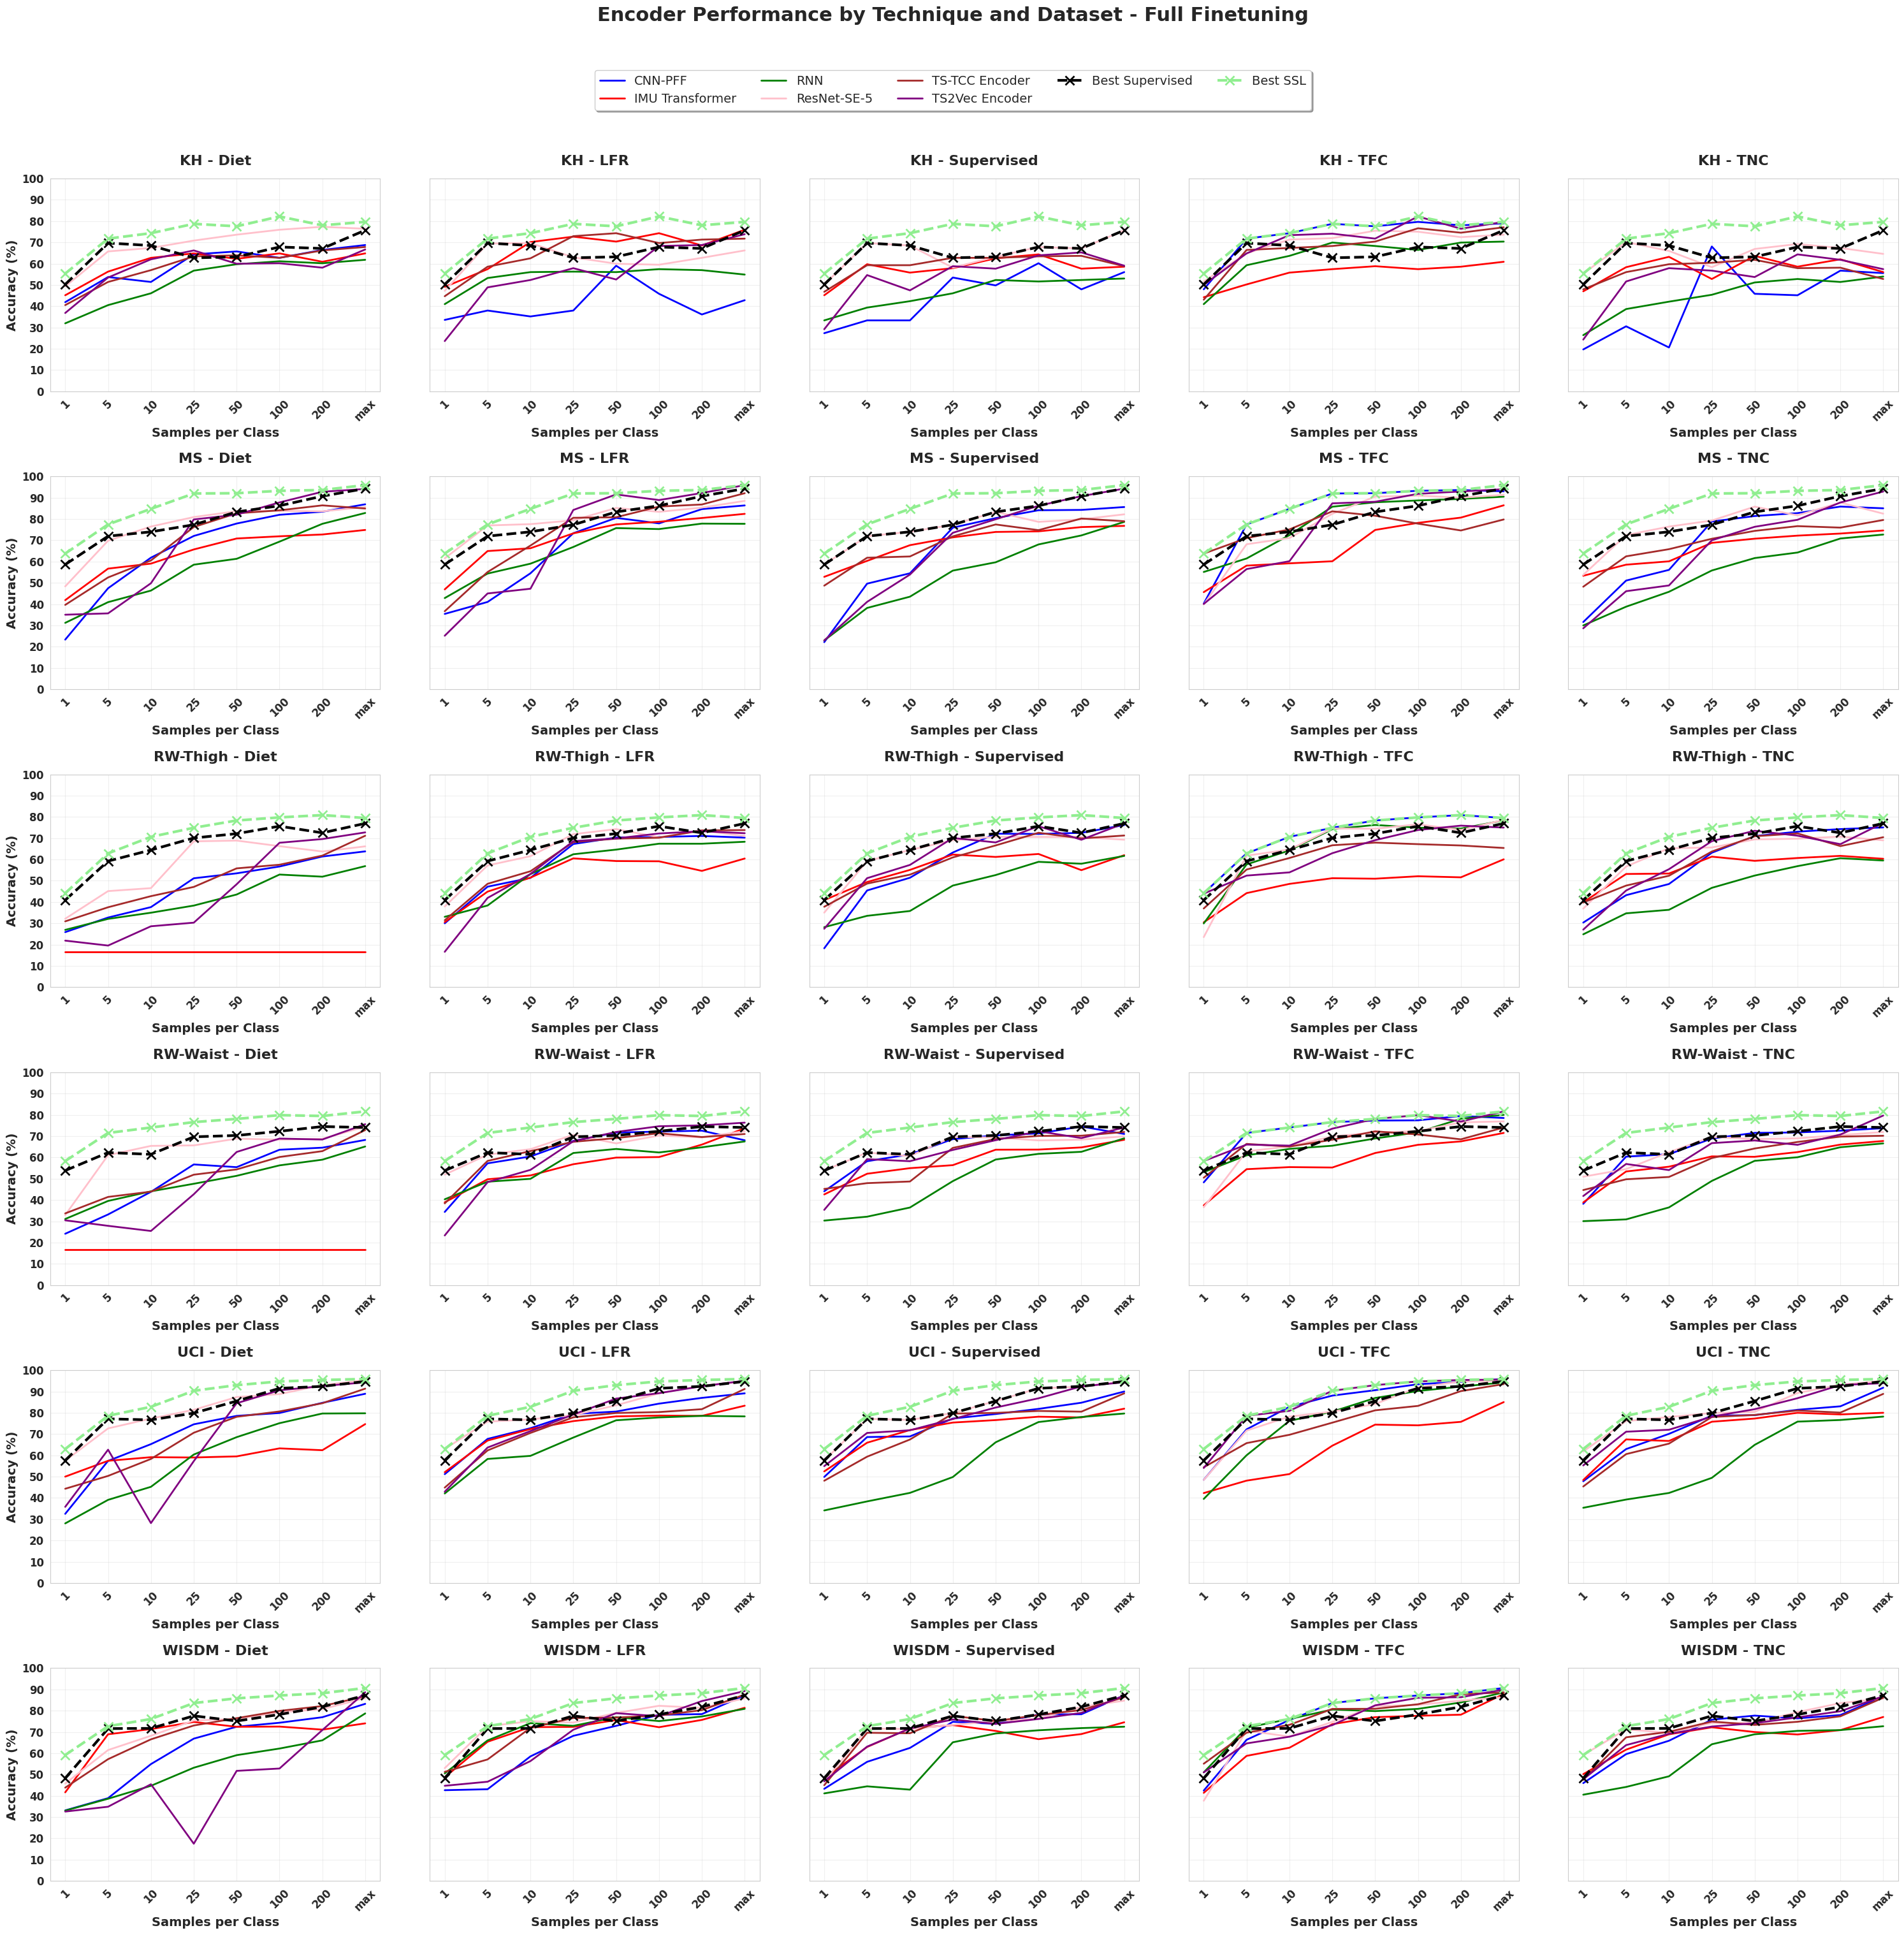

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_technique_backbones_with_supervised_seaborn(df,subtitle_strategy):
    # Set seaborn style
    sns.set_style("whitegrid")
    sns.set_palette("deep")
    
    # Get unique datasets and techniques
    datasets = sorted(df['Dataset'].unique())
    techniques = sorted(df['Technique'].unique())
    
    # Get best supervised and SSL
    best_supervised = df[df['Technique'] == 'Supervised']
    best_supervised = best_supervised.loc[best_supervised.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]

    best_ssl = df[df['Technique'] != 'Supervised']
    best_ssl = best_ssl.loc[best_ssl.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    
    # Create subplots
    fig, axes = plt.subplots(
        len(datasets), 
        len(techniques),
        figsize=(6 * len(techniques), 5 * len(datasets)),
        sharey=True,
        squeeze=False
    )
    
    # Define line styles for backbones (no markers for regular backbones)
    backbone_styles = {
        'CNN-PFF': {'linestyle': '-', 'linewidth': 2, 'color': 'blue'},
        'IMU Transformer': {'linestyle': '-', 'linewidth': 2, 'color': 'red'},
        'RNN': {'linestyle': '-', 'linewidth': 2, 'color': 'green'},
        # 'ResNet-1D': {'linestyle': '-', 'linewidth': 2, 'color': 'orange'},
        'ResNet-SE-5': {'linestyle': '-', 'linewidth': 2, 'color': 'pink'},
        'TS2Vec Encoder': {'linestyle': '-', 'linewidth': 2, 'color': 'purple'},
        'TS-TCC Encoder': {'linestyle': '-', 'linewidth': 2, 'color': 'brown'},
    }
    
    # Define sample order and labels
    sample_order = [1, 5, 10, 25, 50, 100, 200, 1000]
    sample_labels = ['1', '5', '10', '25', '50', '100', '200', 'max']
    
    # Plot each dataset-technique combination
    for i, dataset in enumerate(datasets):
        for j, tech in enumerate(techniques):
            ax = axes[i, j]
            
            # Get all backbones for this technique-dataset combination
            tech_df = df[(df['Dataset'] == dataset) & (df['Technique'] == tech)]
            
            # Plot each backbone curve (without markers)
            for backbone in tech_df['Backbone'].unique():
                backbone_df = tech_df[tech_df['Backbone'] == backbone].sort_values('Data_Percentage')
                
                # Plot line without markers
                ax.plot(
                    range(len(backbone_df)),
                    backbone_df['Mean'],  # Convert to percentage
                    **backbone_styles[backbone],
                    label=backbone if (i == 0 and j == 0) else "",
                )
            
            # Add best supervised curve (with marker)
            sup_df = best_supervised[best_supervised['Dataset'] == dataset].sort_values('Data_Percentage')
            if not sup_df.empty:
                ax.plot(
                    range(len(sup_df)),
                    sup_df['Mean'] ,
                    marker='x',
                    linestyle='--',
                    color='black',
                    linewidth=3,
                    markersize=10,
                    markeredgewidth=2,
                    label="Best Supervised" if (i == 0 and j == 0) else ""
                )
            
            # Add best SSL curve (with marker, light green)
            ssl_df = best_ssl[best_ssl['Dataset'] == dataset].sort_values('Data_Percentage')
            if not ssl_df.empty:
                ax.plot(
                    range(len(ssl_df)),
                    ssl_df['Mean'] ,
                    marker='x',
                    linestyle='--',
                    color='lightgreen',
                    linewidth=3,
                    markersize=10,
                    markeredgewidth=2,
                    label="Best SSL" if (i == 0 and j == 0) else ""
                )
            
            # Set subplot title and labels with bigger, bold fonts
            ax.set_title(f"{dataset} - {tech}", fontsize=16, fontweight='bold', pad=15)
            ax.set_xlabel("Samples per Class", fontsize=14, fontweight='bold')
            if j == 0:
                ax.set_ylabel("Accuracy (%)", fontsize=14, fontweight='bold')
            
            # Set x-axis ticks and labels
            ax.set_xticks(range(len(sample_order)))
            ax.set_xticklabels(sample_labels, rotation=45, fontsize=12, fontweight='bold')
            
            # Set y-axis limits and ticks (0, 10, 20, ..., 100)
            ax.set_ylim(0, 100)
            ax.set_yticks(range(0, 101, 10))
            ax.set_yticklabels([f'{y}' for y in range(0, 101, 10)], fontsize=12, fontweight='bold')
            
            # Add grid
            ax.grid(True, alpha=0.3)
    
    # Create a single legend for the entire figure (moved higher)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, 
               loc='upper center', 
               bbox_to_anchor=(0.5, 0.98),  # Moved higher (1.02 instead of 0.95)
               ncol=len(handles)//2 + 1,
               fontsize=14,  # Bigger legend font
               frameon=True,
               fancybox=True,
               shadow=True)
    
    # Add main title
    fig.suptitle(f"Encoder Performance by Technique and Dataset - {subtitle_strategy}", 
                 fontsize=22,  # Bigger title
                 fontweight='bold',
                 x=0.5,  # Position title to the left
                 y=1.01)  # Same height as legend
    
    # Adjust layout with more space for the higher legend
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.4, wspace=0.15)
    
    return fig

# Usage
fig = plot_technique_backbones_with_supervised_seaborn(best_perf_ft,subtitle_strategy="Full Finetuning")
plt.savefig('technique_backbone_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### freeze

In [16]:
combined_df_freeze = combined_df_freeze.rename(columns={'Dataset Name':'Dataset_','Data Percentage':'Data_Percentage'})
combined_df_freeze

combined_df_freeze['Mean'] = pd.to_numeric(combined_df_freeze['Mean'], errors='coerce')
combined_df_freeze['Std'] = pd.to_numeric(combined_df_freeze['Std'], errors='coerce')
combined_df_freeze


,Backbone,Mean,Std,Mean ± Std,Wins,Losses,Net Score,Dataset,Technique,Performance,Data_Percentage,Dataset_,ft_strategy
0,CNN-PFF,89.704959,1.565280,89.7% ± 1.6%,0,0,0,MS + 1000.0,TFC,89.7% ± 1.6%,1000,MS,Freeze
1,CNN-PFF,89.661835,1.679741,89.7% ± 1.7%,0,0,0,UCI + 1000.0,TFC,89.7% ± 1.7%,1000,UCI,Freeze
2,TS2Vec Encoder,89.178745,1.846524,89.2% ± 1.8%,0,0,0,UCI + 1000.0,TFC,89.2% ± 1.8%,1000,UCI,Freeze
3,CNN-PFF,88.840580,0.950355,88.8% ± 1.0%,0,0,0,UCI + 200.0,TFC,88.8% ± 1.0%,200,UCI,Freeze
4,CNN-PFF,88.826116,1.836358,88.8% ± 1.8%,0,0,0,MS + 200.0,TFC,88.8% ± 1.8%,200,MS,Freeze
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,RNN,24.408436,7.707975,24.4% ± 7.7%,0,0,0,RW-Waist + 5.0,TNC,24.4% ± 7.7%,5,RW-Waist,Freeze
1148,CNN-PFF,23.867034,12.149657,23.9% ± 12.1%,0,0,0,RW-Thigh + 1.0,TNC,23.9% ± 12.1%,1,RW-Thigh,Freeze
1149,RNN,23.132454,7.270823,23.1% ± 7.3%,0,0,0,MS + 1.0,TNC,23.1% ± 7.3%,1,MS,Freeze
1150,CNN-PFF,20.833333,4.224141,20.8% ± 4.2%,0,0,0,KH + 10.0,TNC,20.8% ± 4.2%,10,KH,Freeze


In [17]:

plot_df_freeze = combined_df_freeze.copy()
plot_df_freeze = plot_df_freeze[['Dataset_', 'Backbone', 'Technique', 'Data_Percentage', 'Mean', 'Std']]
plot_df_freeze = plot_df_freeze.rename(columns={'Dataset_':'Dataset'})
# combined_df_ft

                                                                                                                                                
plot_df_freeze
best_perf_freeze = get_best_performance(plot_df_freeze)
best_perf_freeze

fig = plot_technique_backbones_with_supervised(best_perf_freeze)
fig.show()
fig.write_image("backbones_freeze_lr4_lr3_seed.png")
fig.write_html("backbones_freeze_lr4_lr3_seed.html")

In [18]:
performance_tables_freeze = create_technique_performance_tables(best_perf_freeze)
performance_tables_freeze

Performance Table for Technique: Diet


,Dataset,Backbone,Max_Performance,Min_Performance,Avg_Performance,1,5,10,25,50,100,200,1000
0,KH,CNN-PFF,68.8,36.6,59.2,36.6 ± 1.7,51.4 ± 7.3,52.8 ± 13.9,66.0 ± 2.8,68.8 ± 1.4,66.4 ± 1.7,68.3 ± 3.3,63.4 ± 1.7
1,KH,IMU Transformer,67.1,39.4,56.3,39.4 ± 3.6,41.7 ± 8.4,50.9 ± 7.0,61.1 ± 4.2,60.9 ± 6.3,64.1 ± 5.0,65.0 ± 8.3,67.1 ± 7.6
2,KH,RNN,62.0,26.2,50.8,26.2 ± 7.0,40.7 ± 7.3,44.2 ± 2.4,52.5 ± 1.1,60.2 ± 3.1,62.0 ± 2.0,60.2 ± 3.1,60.0 ± 4.9
3,KH,ResNet-SE-5,69.0,33.3,56.2,33.3 ± 6.8,42.8 ± 8.1,45.4 ± 3.9,60.6 ± 3.3,66.2 ± 5.4,66.7 ± 1.8,65.5 ± 4.5,69.0 ± 2.0
4,KH,TS-TCC Encoder,69.2,34.7,56.5,34.7 ± 0.0,44.7 ± 4.4,50.7 ± 2.8,59.3 ± 3.8,61.6 ± 4.0,65.3 ± 4.2,69.2 ± 0.8,66.7 ± 1.8
5,KH,TS2Vec Encoder,70.4,45.1,64.1,45.1 ± 4.6,60.9 ± 6.5,63.4 ± 8.3,65.7 ± 12.4,69.7 ± 2.9,68.1 ± 0.7,70.4 ± 1.4,69.7 ± 1.6
6,MS,CNN-PFF,83.2,24.9,66.8,24.9 ± 3.0,50.8 ± 7.0,63.2 ± 2.2,73.6 ± 4.6,77.1 ± 5.4,79.5 ± 4.3,81.9 ± 4.0,83.2 ± 3.0
7,MS,IMU Transformer,68.7,40.2,58.6,40.2 ± 4.2,48.0 ± 4.3,54.8 ± 2.0,63.8 ± 11.8,62.5 ± 0.8,64.1 ± 2.4,66.9 ± 4.0,68.7 ± 1.7
8,MS,RNN,75.9,25.4,53.8,25.4 ± 3.6,37.4 ± 2.5,40.7 ± 2.2,54.6 ± 1.8,60.5 ± 1.9,64.9 ± 3.3,71.0 ± 1.2,75.9 ± 1.7
9,MS,ResNet-SE-5,78.8,34.5,62.9,34.5 ± 4.7,50.0 ± 5.1,47.4 ± 3.2,64.0 ± 4.3,75.1 ± 3.9,75.3 ± 0.1,78.0 ± 0.3,78.8 ± 1.5


Performance Table for Technique: LFR


,Dataset,Backbone,Max_Performance,Min_Performance,Avg_Performance,1,5,10,25,50,100,200,1000
0,KH,CNN-PFF,59.3,35.6,47.7,41.0 ± 8.3,42.1 ± 20.4,35.6 ± 16.8,48.1 ± 6.6,52.5 ± 11.0,59.3 ± 8.9,53.5 ± 10.3,49.1 ± 9.6
1,KH,IMU Transformer,64.4,44.7,59.5,44.7 ± 7.7,58.3 ± 9.8,55.1 ± 7.9,63.7 ± 7.7,63.2 ± 4.6,63.4 ± 4.6,64.4 ± 6.0,63.4 ± 7.5
2,KH,RNN,62.0,44.9,56.0,44.9 ± 3.8,49.5 ± 4.2,50.7 ± 2.5,56.7 ± 1.4,62.0 ± 2.4,60.6 ± 3.1,61.8 ± 1.4,61.3 ± 2.0
3,KH,ResNet-SE-5,61.3,34.7,49.3,35.6 ± 2.0,37.5 ± 3.9,34.7 ± 1.2,47.0 ± 5.3,56.9 ± 0.7,60.6 ± 1.6,61.3 ± 0.4,60.9 ± 1.4
4,KH,TS-TCC Encoder,75.2,41.0,64.0,41.0 ± 3.9,50.2 ± 3.4,57.6 ± 1.8,69.2 ± 1.4,71.3 ± 2.4,72.9 ± 2.1,75.2 ± 4.0,74.8 ± 1.4
5,KH,TS2Vec Encoder,70.1,21.1,47.2,25.7 ± 9.2,21.1 ± 0.4,31.0 ± 8.8,50.0 ± 15.5,55.1 ± 7.1,58.8 ± 6.2,65.7 ± 3.5,70.1 ± 0.7
6,MS,CNN-PFF,83.8,26.4,62.5,26.4 ± 15.4,38.1 ± 10.3,50.5 ± 19.1,63.5 ± 13.4,73.8 ± 6.0,80.2 ± 3.9,83.5 ± 1.3,83.8 ± 1.5
7,MS,IMU Transformer,82.5,37.5,65.3,37.5 ± 2.8,49.8 ± 13.5,53.3 ± 17.8,68.6 ± 10.2,72.0 ± 8.4,76.9 ± 4.4,81.5 ± 0.2,82.5 ± 1.3
8,MS,RNN,80.2,36.2,61.2,36.2 ± 3.4,48.9 ± 6.0,51.9 ± 3.4,58.9 ± 5.0,64.2 ± 0.9,70.9 ± 0.2,78.3 ± 2.1,80.2 ± 0.9
9,MS,ResNet-SE-5,80.5,33.0,52.8,33.0 ± 0.1,35.1 ± 3.1,36.6 ± 3.3,37.4 ± 1.3,55.2 ± 4.5,68.0 ± 5.0,76.6 ± 3.6,80.5 ± 2.2


Performance Table for Technique: TFC


,Dataset,Backbone,Max_Performance,Min_Performance,Avg_Performance,1,5,10,25,50,100,200,1000
0,KH,CNN-PFF,75.2,40.3,65.8,40.3 ± 9.7,56.2 ± 9.4,59.3 ± 3.8,73.4 ± 2.1,74.5 ± 2.9,73.6 ± 3.5,75.2 ± 3.1,73.8 ± 4.0
1,KH,IMU Transformer,54.2,41.0,51.1,41.0 ± 10.9,53.0 ± 6.5,51.4 ± 0.7,50.7 ± 3.0,52.1 ± 2.5,52.8 ± 3.2,53.7 ± 1.4,54.2 ± 3.2
2,KH,RNN,58.1,39.8,51.2,39.8 ± 4.0,50.0 ± 6.2,49.3 ± 3.2,48.8 ± 4.1,52.8 ± 7.3,53.2 ± 2.4,58.1 ± 3.1,57.9 ± 5.4
3,KH,ResNet-SE-5,68.8,34.0,61.0,34.0 ± 10.1,57.4 ± 1.6,59.7 ± 4.9,64.8 ± 2.8,67.1 ± 2.4,68.8 ± 3.0,68.3 ± 0.4,67.8 ± 2.8
4,KH,TS-TCC Encoder,67.8,31.2,58.3,31.2 ± 9.0,58.6 ± 1.4,51.4 ± 7.3,65.3 ± 6.8,64.1 ± 5.2,67.6 ± 5.3,67.8 ± 1.7,60.4 ± 10.9
5,KH,TS2Vec Encoder,65.7,37.0,60.1,37.0 ± 4.2,60.4 ± 2.5,61.1 ± 7.2,64.1 ± 5.0,64.8 ± 1.1,65.7 ± 4.5,63.4 ± 9.6,64.1 ± 8.0
6,MS,CNN-PFF,89.7,26.9,76.2,26.9 ± 6.9,67.6 ± 2.0,74.7 ± 6.0,86.2 ± 1.4,86.9 ± 1.1,88.7 ± 0.8,88.8 ± 1.8,89.7 ± 1.6
7,MS,IMU Transformer,58.5,42.7,52.9,42.7 ± 9.2,49.1 ± 3.9,51.5 ± 4.3,57.3 ± 4.8,54.3 ± 8.3,55.0 ± 4.3,55.1 ± 3.8,58.5 ± 8.3
8,MS,RNN,72.5,32.9,62.8,32.9 ± 16.6,52.2 ± 1.2,61.0 ± 2.0,69.0 ± 2.7,71.0 ± 3.2,72.5 ± 4.2,71.9 ± 1.8,71.8 ± 1.9
9,MS,ResNet-SE-5,76.1,18.3,62.1,18.3 ± 5.8,52.4 ± 7.2,57.3 ± 2.6,69.3 ± 0.9,72.3 ± 3.7,75.4 ± 2.8,76.1 ± 2.4,75.7 ± 2.5


Performance Table for Technique: TNC


,Dataset,Backbone,Max_Performance,Min_Performance,Avg_Performance,1,5,10,25,50,100,200,1000
0,KH,CNN-PFF,54.6,20.8,39.1,31.7 ± 11.8,27.5 ± 8.3,20.8 ± 4.2,46.5 ± 8.7,35.0 ± 8.5,51.9 ± 11.3,44.4 ± 18.2,54.6 ± 15.5
1,KH,IMU Transformer,59.0,32.4,50.6,32.4 ± 12.2,44.7 ± 8.3,48.6 ± 10.8,52.3 ± 4.1,54.4 ± 7.6,55.1 ± 1.4,59.0 ± 7.5,58.3 ± 6.2
2,KH,RNN,53.9,27.1,42.3,32.6 ± 0.7,34.3 ± 4.2,27.1 ± 7.3,42.1 ± 3.8,44.7 ± 1.4,50.2 ± 2.6,53.5 ± 2.8,53.9 ± 2.8
3,KH,ResNet-SE-5,61.8,33.3,48.9,33.3 ± 1.4,37.7 ± 4.2,36.3 ± 2.4,47.9 ± 3.6,53.7 ± 3.6,58.8 ± 3.3,61.8 ± 3.7,61.6 ± 5.4
4,KH,TS-TCC Encoder,68.5,47.0,62.8,47.0 ± 1.7,56.2 ± 4.3,62.3 ± 5.2,66.7 ± 2.5,66.9 ± 1.7,67.1 ± 2.8,68.5 ± 7.1,67.8 ± 1.4
5,KH,TS2Vec Encoder,60.0,33.8,48.3,34.0 ± 7.3,42.4 ± 11.5,33.8 ± 13.6,47.0 ± 25.1,58.3 ± 9.2,60.0 ± 9.2,57.4 ± 7.0,53.2 ± 2.2
6,MS,CNN-PFF,82.9,37.7,62.9,37.7 ± 11.8,39.1 ± 10.7,49.0 ± 3.9,66.0 ± 2.5,70.5 ± 5.3,77.4 ± 4.2,82.9 ± 1.0,80.9 ± 5.3
7,MS,IMU Transformer,61.9,46.1,54.2,46.1 ± 5.6,48.2 ± 4.4,47.4 ± 1.3,53.4 ± 3.2,55.9 ± 0.9,59.8 ± 3.7,60.9 ± 3.0,61.9 ± 2.1
8,MS,RNN,66.2,23.1,44.9,23.1 ± 7.3,31.5 ± 6.9,36.1 ± 9.0,43.5 ± 2.1,48.0 ± 3.1,51.1 ± 1.8,59.3 ± 1.5,66.2 ± 1.0
9,MS,ResNet-SE-5,80.4,34.8,59.7,46.5 ± 8.5,34.8 ± 1.8,38.0 ± 3.6,57.1 ± 2.9,68.8 ± 1.3,72.3 ± 1.7,79.6 ± 2.9,80.4 ± 1.0


{'Diet':      Dataset         Backbone Max_Performance Min_Performance Avg_Performance  \
 0         KH          CNN-PFF            68.8            36.6            59.2   
 1         KH  IMU Transformer            67.1            39.4            56.3   
 2         KH              RNN            62.0            26.2            50.8   
 3         KH      ResNet-SE-5            69.0            33.3            56.2   
 4         KH   TS-TCC Encoder            69.2            34.7            56.5   
 5         KH   TS2Vec Encoder            70.4            45.1            64.1   
 6         MS          CNN-PFF            83.2            24.9            66.8   
 7         MS  IMU Transformer            68.7            40.2            58.6   
 8         MS              RNN            75.9            25.4            53.8   
 9         MS      ResNet-SE-5            78.8            34.5            62.9   
 10        MS   TS-TCC Encoder            86.4            37.6            63.0   
 11     

In [19]:
performance_tables

{'Diet':      Dataset         Backbone Max_Performance Min_Performance Avg_Performance  \
 0         KH          CNN-PFF            68.8            41.9            59.4   
 1         KH  IMU Transformer            64.8            45.1            60.2   
 2         KH              RNN            61.8            31.9            52.3   
 3         KH      ResNet-SE-5            77.3            49.3            69.6   
 4         KH   TS-TCC Encoder            67.8            40.5            59.1   
 5         KH   TS2Vec Encoder            66.7            36.8            57.9   
 6         MS          CNN-PFF            86.9            23.3            66.9   
 7         MS  IMU Transformer            74.9            41.9            64.2   
 8         MS              RNN            82.8            31.2            58.5   
 9         MS      ResNet-SE-5            85.6            48.3            76.5   
 10        MS   TS-TCC Encoder            86.4            39.6            70.9   
 11     

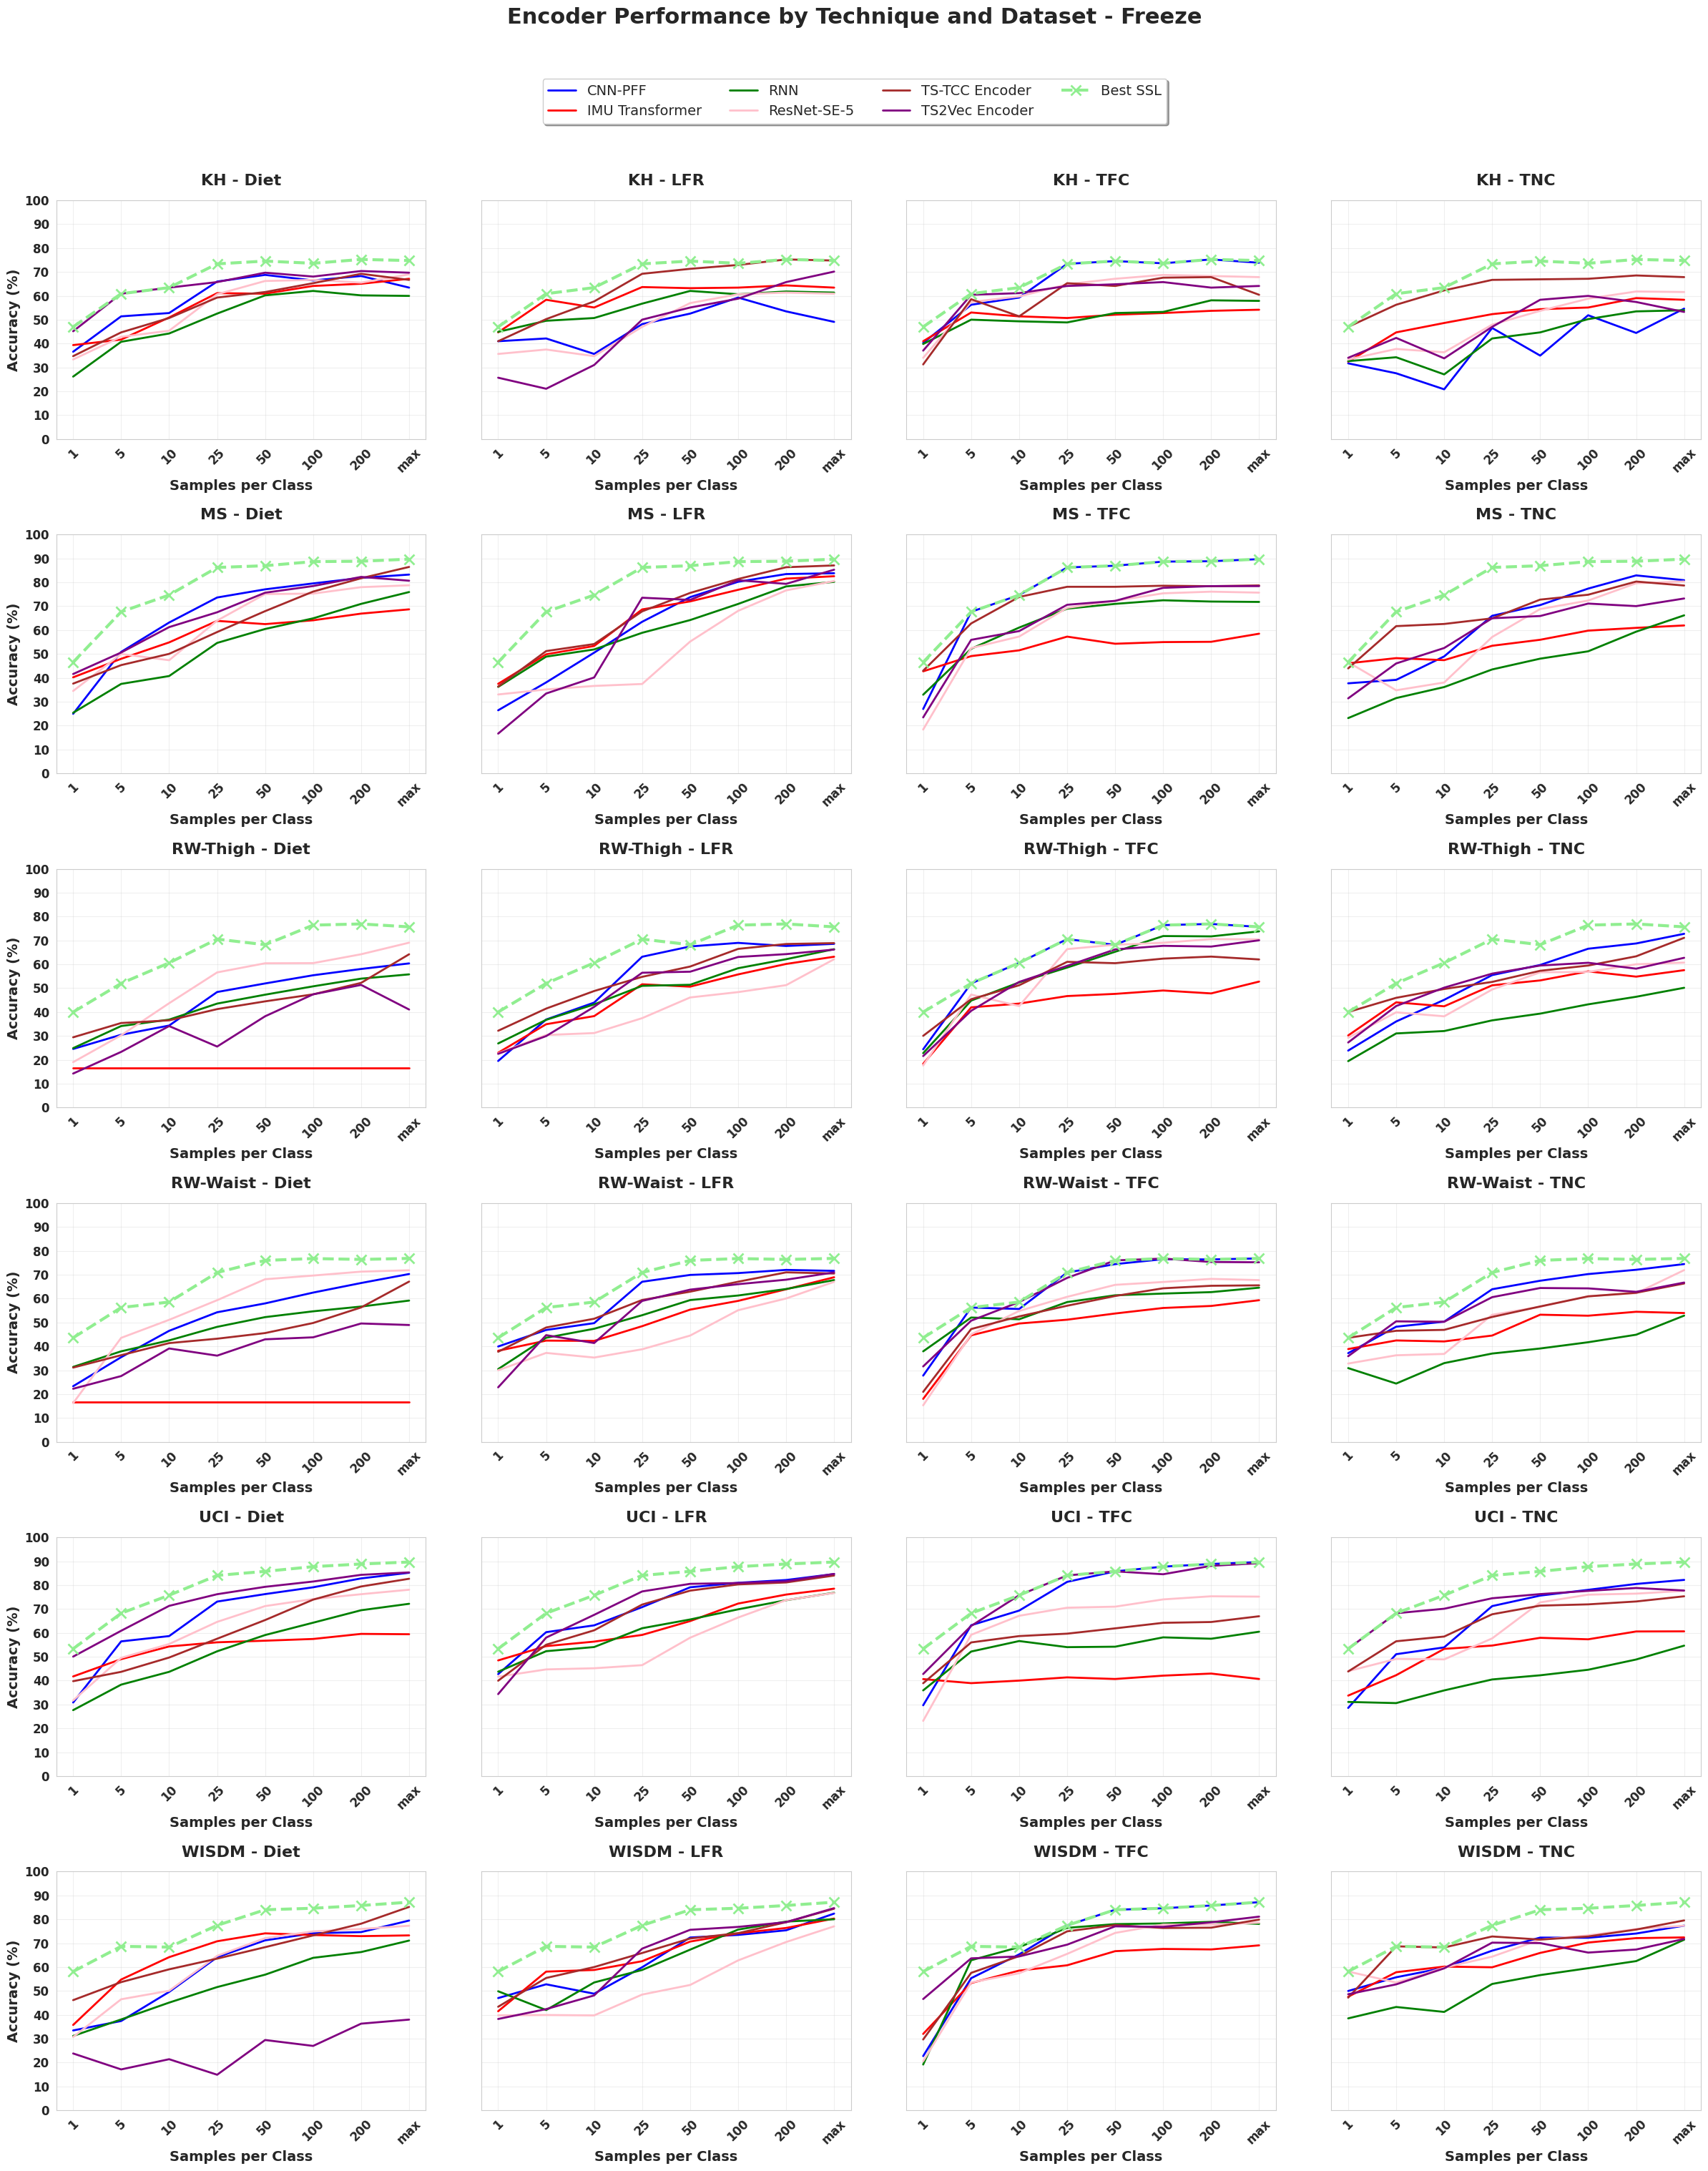

In [20]:
fig = plot_technique_backbones_with_supervised_seaborn(best_perf_freeze,subtitle_strategy="Freeze")
plt.savefig('technique_backbone_comparison_freeze.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
best_perf_freeze

,Dataset,Backbone,Technique,Data_Percentage,Mean,Std
804,KH,CNN-PFF,Diet,1,36.574074,1.747648
793,KH,IMU Transformer,Diet,1,39.351852,3.563613
832,KH,RNN,Diet,1,26.157408,6.990588
818,KH,ResNet-SE-5,Diet,1,33.333333,6.839485
812,KH,TS-TCC Encoder,Diet,1,34.722221,0.000000
...,...,...,...,...,...,...
900,WISDM,IMU Transformer,TNC,1000,72.439837,1.074126
911,WISDM,RNN,TNC,1000,71.466974,0.389742
880,WISDM,ResNet-SE-5,TNC,1000,77.368150,1.030684
871,WISDM,TS-TCC Encoder,TNC,1000,79.557093,0.825727


In [22]:
best_perf_ft

,Dataset,Backbone,Technique,Data_Percentage,Mean,Std
1087,KH,CNN-PFF,Diet,1,41.898149,3.425613
1077,KH,IMU Transformer,Diet,1,45.138889,5.242939
1118,KH,RNN,Diet,1,31.944445,6.624578
1064,KH,ResNet-SE-5,Diet,1,49.305554,1.837327
1092,KH,TS-TCC Encoder,Diet,1,40.509259,2.806564
...,...,...,...,...,...,...
1204,WISDM,IMU Transformer,TNC,1000,77.060934,7.193912
1230,WISDM,RNN,TNC,1000,72.708652,0.096646
1168,WISDM,ResNet-SE-5,TNC,1000,85.752690,1.257350
1165,WISDM,TS-TCC Encoder,TNC,1000,86.098311,0.618030


## plot to   paper

In [23]:
import pandas as pd

def generate_best_performance_table(df):
    """
    Generate a table showing best supervised and SSL performance by dataset and data percentage.
    
    Args:
        df: DataFrame containing performance data with columns:
            - Dataset
            - Data_Percentage
            - Technique
            - Backbone
            - Mean
            - Std
    
    Returns:
        A formatted DataFrame with best performance comparisons
    """
    # Get best supervised performance for each dataset and data percentage
    supervised = df[df['Technique'] == 'Supervised']
    best_supervised = supervised.loc[supervised.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    best_supervised = best_supervised[['Dataset', 'Data_Percentage', 'Backbone', 'Mean', 'Std']]
    best_supervised['Method'] = best_supervised['Backbone'] + ' (Supervised)'
    
    # Get best SSL performance (excluding supervised)
    ssl = df[df['Technique'] != 'Supervised']
    best_ssl = ssl.loc[ssl.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    best_ssl = best_ssl[['Dataset', 'Data_Percentage', 'Backbone', 'Technique', 'Mean', 'Std']]
    best_ssl['Method'] = best_ssl['Backbone'] + ',' + best_ssl['Technique']
    
    # Merge the results
    result = pd.merge(
        best_supervised,
        best_ssl,
        on=['Dataset', 'Data_Percentage'],
        suffixes=('_supervised', '_ssl')
    )
    
    # Calculate SSL impact
    result['SSL_Impact'] = result['Mean_ssl'] - result['Mean_supervised']
    
    # Format the output
    result['Best_Supervised'] = result.apply(
        lambda x: f"{x['Mean_supervised']:.1f}±{x['Std_supervised']:.1f}({x['Method_supervised']})", 
        axis=1
    )
    result['Best_SSL'] = result.apply(
        lambda x: f"{x['Mean_ssl']:.1f}±{x['Std_ssl']:.1f}({x['Method_ssl']})", 
        axis=1
    )
    result['SSL_Impact'] = result['SSL_Impact'].apply(lambda x: f"{x:+.1f}")
    
    # Select and order columns
    final = result[[
        'Dataset', 
        'Data_Percentage', 
        'Best_Supervised', 
        'Best_SSL', 
        'SSL_Impact'
    ]]
    
    return final.sort_values(['Dataset', 'Data_Percentage'])


best_performance_table = generate_best_performance_table(best_perf_ft)
best_performance_table
# print(best_performance_table.to_markdown(index=False))

,Dataset,Data_Percentage,Best_Supervised,Best_SSL,SSL_Impact
0,KH,1,50.2±5.0(ResNet-SE-5 (Supervised)),"55.3±3.8(ResNet-SE-5,TNC)",+5.1
1,KH,5,69.7±0.4(ResNet-SE-5 (Supervised)),"71.8±3.6(CNN-PFF,TFC)",+2.1
2,KH,10,68.5±6.1(ResNet-SE-5 (Supervised)),"74.3±6.1(CNN-PFF,TFC)",+5.8
3,KH,25,62.7±2.0(TS-TCC Encoder (Supervised)),"78.7±3.2(CNN-PFF,TFC)",+16.0
4,KH,50,63.2±7.9(ResNet-SE-5 (Supervised)),"77.5±1.7(CNN-PFF,TFC)",+14.4
5,KH,100,67.8±7.0(ResNet-SE-5 (Supervised)),"82.2±6.7(TS2Vec Encoder,TFC)",+14.4
6,KH,200,67.1±7.6(ResNet-SE-5 (Supervised)),"78.0±0.8(CNN-PFF,TFC)",+10.9
7,KH,1000,75.7±0.7(ResNet-SE-5 (Supervised)),"79.6±9.6(TS2Vec Encoder,TFC)",+3.9
8,MS,1,58.6±5.2(ResNet-SE-5 (Supervised)),"63.7±8.2(TS-TCC Encoder,TFC)",+5.1
9,MS,5,71.9±2.2(ResNet-SE-5 (Supervised)),"77.5±4.7(CNN-PFF,TFC)",+5.5


In [24]:
def generate_complete_comparison_table(best_perf_freeze, best_perf_ft):
    """
    Generate a complete comparison table showing supervised, SSL freeze, and SSL full finetune
    """
    # Get best supervised performance from full finetune (since freeze doesn't have supervised)
    supervised = best_perf_ft[best_perf_ft['Technique'] == 'Supervised']
    best_supervised = supervised.loc[supervised.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    
    # Get best SSL freeze performance
    ssl_freeze = best_perf_freeze[best_perf_freeze['Technique'] == 'TFC']
    best_ssl_freeze = ssl_freeze.loc[ssl_freeze.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    
    # Get best SSL freeze performance WITHOUT TFC
    ssl_freeze_no_tfc =  best_perf_freeze[best_perf_freeze['Technique'] != 'Supervised']
    ssl_freeze_no_tfc =  ssl_freeze_no_tfc[ssl_freeze_no_tfc['Technique'] != 'TFC']
    best_ssl_freeze_no_tfc = ssl_freeze_no_tfc.loc[ssl_freeze_no_tfc.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    
    # Get best SSL full finetune performance
    ssl_ft = best_perf_ft[best_perf_ft['Technique'] == 'TFC']
    best_ssl_ft = ssl_ft.loc[ssl_ft.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    
    # Get best SSL full finetune performance WITHOUT TFC
    ssl_ft_no_tfc = best_perf_ft[best_perf_ft['Technique'] != 'Supervised']
    ssl_ft_no_tfc = ssl_ft_no_tfc[ssl_ft_no_tfc['Technique'] != 'TFC']
    best_ssl_ft_no_tfc = ssl_ft_no_tfc.loc[ssl_ft_no_tfc.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    
    # Create a combined table
    result = best_supervised[['Dataset', 'Data_Percentage', 'Mean', 'Std', 'Backbone']].copy()
    result = result.rename(columns={'Mean': 'Mean_supervised', 'Std': 'Std_supervised', 'Backbone': 'Backbone_supervised'})
    
    # Merge with freeze results
    result = pd.merge(
        result,
        best_ssl_freeze[['Dataset', 'Data_Percentage', 'Mean', 'Std', 'Backbone', 'Technique']],
        on=['Dataset', 'Data_Percentage'],
        how='left',
        suffixes=('', '_freeze')
    )
    result = result.rename(columns={'Mean': 'Mean_freeze', 'Std': 'Std_freeze', 'Backbone': 'Backbone_freeze', 'Technique': 'Technique_freeze'})
    
    # Merge with freeze results WITHOUT TFC
    result = pd.merge(
        result,
        best_ssl_freeze_no_tfc[['Dataset', 'Data_Percentage', 'Mean', 'Std', 'Backbone', 'Technique']],
        on=['Dataset', 'Data_Percentage'],
        how='left',
        suffixes=('', '_freeze_no_tfc')
    )
    result = result.rename(columns={'Mean': 'Mean_freeze_no_tfc', 'Std': 'Std_freeze_no_tfc', 
                                  'Backbone': 'Backbone_freeze_no_tfc', 'Technique': 'Technique_freeze_no_tfc'})
    
    # Merge with full finetune results
    result = pd.merge(
        result,
        best_ssl_ft[['Dataset', 'Data_Percentage', 'Mean', 'Std', 'Backbone', 'Technique']],
        on=['Dataset', 'Data_Percentage'],
        how='left',
        suffixes=('', '_ft')
    )
    result = result.rename(columns={'Mean': 'Mean_ft', 'Std': 'Std_ft', 'Backbone': 'Backbone_ft', 'Technique': 'Technique_ft'})
    
    # Merge with full finetune results WITHOUT TFC
    result = pd.merge(
        result,
        best_ssl_ft_no_tfc[['Dataset', 'Data_Percentage', 'Mean', 'Std', 'Backbone', 'Technique']],
        on=['Dataset', 'Data_Percentage'],
        how='left',
        suffixes=('', '_ft_no_tfc')
    )
    result = result.rename(columns={'Mean': 'Mean_ft_no_tfc', 'Std': 'Std_ft_no_tfc', 
                                  'Backbone': 'Backbone_ft_no_tfc', 'Technique': 'Technique_ft_no_tfc'})
    
    # Calculate impacts
    result['SSL_Freeze_Impact'] = result['Mean_freeze'] - result['Mean_supervised']
    result['SSL_FT_Impact'] = result['Mean_ft'] - result['Mean_supervised']
    result['FT_vs_Freeze_Impact'] = result['Mean_ft'] - result['Mean_freeze']
    
    # Calculate impacts without TFC
    result['SSL_Freeze_Impact_no_TFC'] = result['Mean_freeze_no_tfc'] - result['Mean_supervised']
    result['SSL_FT_Impact_no_TFC'] = result['Mean_ft_no_tfc'] - result['Mean_supervised']
    result['TFC_Impact_Freeze'] = result['Mean_freeze'] - result['Mean_freeze_no_tfc']
    result['TFC_Impact_FT'] = result['Mean_ft'] - result['Mean_ft_no_tfc']
    
    # Format the output
    result['Best_Supervised'] = result.apply(
        lambda x: f"{x['Mean_supervised']:.1f}±{x['Std_supervised']:.1f} ({x['Backbone_supervised']})", 
        axis=1
    )
    
    result['Best_SSL_Freeze'] = result.apply(
        lambda x: f"{x['Mean_freeze']:.1f}±{x['Std_freeze']:.1f} ({x['Backbone_freeze']}, {x['Technique_freeze']})" 
        if pd.notna(x['Mean_freeze']) else "N/A", 
        axis=1
    )
    
    result['Best_SSL_Freeze_no_TFC'] = result.apply(
        lambda x: f"{x['Mean_freeze_no_tfc']:.1f}±{x['Std_freeze_no_tfc']:.1f} ({x['Backbone_freeze_no_tfc']}, {x['Technique_freeze_no_tfc']})" 
        if pd.notna(x['Mean_freeze_no_tfc']) else "N/A", 
        axis=1
    )
    
    result['Best_SSL_FT'] = result.apply(
        lambda x: f"{x['Mean_ft']:.1f}±{x['Std_ft']:.1f} ({x['Backbone_ft']}, {x['Technique_ft']})", 
        axis=1
    )
    
    result['Best_SSL_FT_no_TFC'] = result.apply(
        lambda x: f"{x['Mean_ft_no_tfc']:.1f}±{x['Std_ft_no_tfc']:.1f} ({x['Backbone_ft_no_tfc']}, {x['Technique_ft_no_tfc']})", 
        axis=1
    )
    
    # Format impact columns
    for impact_col in ['SSL_Freeze_Impact', 'SSL_FT_Impact', 'FT_vs_Freeze_Impact',
                      'SSL_Freeze_Impact_no_TFC', 'SSL_FT_Impact_no_TFC', 
                      'TFC_Impact_Freeze', 'TFC_Impact_FT']:
        result[impact_col] = result[impact_col].apply(
            lambda x: f"{x:+.1f}" if pd.notna(x) else "N/A"
        )
    
    # Select and order columns
    final = result[[
        'Dataset', 
        'Data_Percentage', 
        'Best_Supervised', 
        'Best_SSL_Freeze',
        'Best_SSL_Freeze_no_TFC',
        'SSL_Freeze_Impact',
        'SSL_Freeze_Impact_no_TFC',
        'TFC_Impact_Freeze',
        'Best_SSL_FT', 
        'Best_SSL_FT_no_TFC',
        'SSL_FT_Impact',
        'SSL_FT_Impact_no_TFC',
        'TFC_Impact_FT',
        'FT_vs_Freeze_Impact'
    ]]
    
    # Calculate summary statistics
    summary_stats = calculate_summary_statistics(result)
    
    return final.sort_values(['Dataset', 'Data_Percentage']), summary_stats

def calculate_summary_statistics(result_df):
    """
    Calculate summary statistics for the comparison table
    """
    summary = {}
    
    # Calculate average performance for each strategy
    summary['avg_supervised'] = result_df['Mean_supervised'].mean()
    summary['std_supervised'] = result_df['Std_supervised'].mean()
    
    summary['avg_freeze'] = result_df['Mean_freeze'].mean()
    summary['std_freeze'] = result_df['Std_freeze'].mean()
    
    summary['avg_freeze_no_tfc'] = result_df['Mean_freeze_no_tfc'].mean()
    summary['std_freeze_no_tfc'] = result_df['Std_freeze_no_tfc'].mean()
    
    summary['avg_ft'] = result_df['Mean_ft'].mean()
    summary['std_ft'] = result_df['Std_ft'].mean()
    
    summary['avg_ft_no_tfc'] = result_df['Mean_ft_no_tfc'].mean()
    summary['std_ft_no_tfc'] = result_df['Std_ft_no_tfc'].mean()
    
    # Calculate impact statistics
    # summary['freeze_impact_positive'] = (result_df['SSL_Freeze_Impact'] > 0).sum()
    # summary['freeze_impact_negative'] = (result_df['SSL_Freeze_Impact'] <= 0).sum()
    # summary['freeze_impact_high_positive'] = (result_df['SSL_Freeze_Impact'] >= 5).sum()
    
    # summary['ft_impact_positive'] = (result_df['SSL_FT_Impact'] > 0).sum()
    # summary['ft_impact_negative'] = (result_df['SSL_FT_Impact'] <= 0).sum()
    # summary['ft_impact_high_positive'] = (result_df['SSL_FT_Impact'] >= 5).sum()
    
    # summary['ft_no_tfc_impact_positive'] = (result_df['SSL_FT_Impact_no_TFC'] > 0).sum()
    # summary['ft_no_tfc_impact_negative'] = (result_df['SSL_FT_Impact_no_TFC'] <= 0).sum()
    # summary['ft_no_tfc_impact_high_positive'] = (result_df['SSL_FT_Impact_no_TFC'] >= 5).sum()
    
    # # Calculate TFC impact statistics
    # summary['tfc_improves_freeze'] = (result_df['TFC_Impact_Freeze'] > 0).sum()
    # summary['tfc_improves_ft'] = (result_df['TFC_Impact_FT'] > 0).sum()
    # summary['avg_tfc_impact_freeze'] = result_df['TFC_Impact_Freeze'].mean()
    # summary['avg_tfc_impact_ft'] = result_df['TFC_Impact_FT'].mean()
    
    return summary

# Generate the complete comparison table
complete_comparison, summary_stats = generate_complete_comparison_table(best_perf_freeze, best_perf_ft)
print("Complete Comparison Table (with and without TFC):")
display(complete_comparison)

# Print summary statistics
print("\n" + "="*100)
print("SUMMARY STATISTICS:")
print("="*100)

print(f"\nAverage Performance:")
print(f"Supervised: {summary_stats['avg_supervised']:.1f} ± {summary_stats['std_supervised']:.1f}")
print(f"Freeze: {summary_stats['avg_freeze']:.1f} ± {summary_stats['std_freeze']:.1f}")
print(f"Freeze (no TFC): {summary_stats['avg_freeze_no_tfc']:.1f} ± {summary_stats['std_freeze_no_tfc']:.1f}")
print(f"Full Finetune: {summary_stats['avg_ft']:.1f} ± {summary_stats['std_ft']:.1f}")
print(f"Full Finetune (no TFC): {summary_stats['avg_ft_no_tfc']:.1f} ± {summary_stats['std_ft_no_tfc']:.1f}")

print(f"\nImpact Statistics (Freeze vs Supervised):")
# print(f"Positive impacts: {summary_stats['freeze_impact_positive']}")
# print(f"Negative impacts: {summary_stats['freeze_impact_negative']}")
# print(f"High positive impacts (≥+5): {summary_stats['freeze_impact_high_positive']}")

# print(f"\nImpact Statistics (Full Finetune vs Supervised):")
# print(f"Positive impacts: {summary_stats['ft_impact_positive']}")
# print(f"Negative impacts: {summary_stats['ft_impact_negative']}")
# print(f"High positive impacts (≥+5): {summary_stats['ft_impact_high_positive']}")
# # 
# print(f"\nImpact Statistics (Full Finetune no TFC vs Supervised):")
# print(f"Positive impacts: {summary_stats['ft_no_tfc_impact_positive']}")
# print(f"Negative impacts: {summary_stats['ft_no_tfc_impact_negative']}")
# print(f"High positive impacts (≥+5): {summary_stats['ft_no_tfc_impact_high_positive']}")

# print(f"\nTFC Impact Statistics:")
# print(f"TFC improves Freeze in {summary_stats['tfc_improves_freeze']} cases")
# print(f"TFC improves Full Finetune in {summary_stats['tfc_improves_ft']} cases")
# print(f"Average TFC impact on Freeze: {summary_stats['avg_tfc_impact_freeze']:+.2f}%")
# print(f"Average TFC impact on Full Finetune: {summary_stats['avg_tfc_impact_ft']:+.2f}%")

# Create a summary row for the table
summary_row = {
    'Dataset': 'Summary',
    'Data_Percentage': '',
    'Best_Supervised': f"{summary_stats['avg_supervised']:.1f}±{summary_stats['std_supervised']:.1f}",
    'Best_SSL_Freeze': f"{summary_stats['avg_freeze']:.1f}±{summary_stats['std_freeze']:.1f}",
    'Best_SSL_Freeze_no_TFC': f"{summary_stats['avg_freeze_no_tfc']:.1f}±{summary_stats['std_freeze_no_tfc']:.1f}",
    # 'SSL_Freeze_Impact': f"≥+5: {summary_stats['freeze_impact_high_positive']}",
    'SSL_Freeze_Impact_no_TFC': '',
    'TFC_Impact_Freeze': '',
    'Best_SSL_FT': f"{summary_stats['avg_ft']:.1f}±{summary_stats['std_ft']:.1f}",
    'Best_SSL_FT_no_TFC': f"{summary_stats['avg_ft_no_tfc']:.1f}±{summary_stats['std_ft_no_tfc']:.1f}",
    # 'SSL_FT_Impact': f"≥+5: {summary_stats['ft_impact_high_positive']}",
    # 'SSL_FT_Impact_no_TFC': f"≥+5: {summary_stats['ft_no_tfc_impact_high_positive']}",
    'TFC_Impact_FT': '',
    'FT_vs_Freeze_Impact': ''
}

print(f"\nSummary Row for Table:")
for key, value in summary_row.items():
    print(f"{key}: {value}")

Complete Comparison Table (with and without TFC):


,Dataset,Data_Percentage,Best_Supervised,Best_SSL_Freeze,Best_SSL_Freeze_no_TFC,SSL_Freeze_Impact,SSL_Freeze_Impact_no_TFC,TFC_Impact_Freeze,Best_SSL_FT,Best_SSL_FT_no_TFC,SSL_FT_Impact,SSL_FT_Impact_no_TFC,TFC_Impact_FT,FT_vs_Freeze_Impact
0,KH,1,50.2±5.0 (ResNet-SE-5),"41.0±10.9 (IMU Transformer, TFC)","47.0±1.7 (TS-TCC Encoder, TNC)",-9.3,-3.2,-6.0,"51.6±6.3 (ResNet-SE-5, TFC)","55.3±3.8 (ResNet-SE-5, TNC)",+1.4,+5.1,-3.7,+10.6
1,KH,5,69.7±0.4 (ResNet-SE-5),"60.4±2.5 (TS2Vec Encoder, TFC)","60.9±6.5 (TS2Vec Encoder, Diet)",-9.3,-8.8,-0.5,"71.8±3.6 (CNN-PFF, TFC)","70.1±2.1 (ResNet-SE-5, TNC)",+2.1,+0.5,+1.6,+11.3
2,KH,10,68.5±6.1 (ResNet-SE-5),"61.1±7.2 (TS2Vec Encoder, TFC)","63.4±8.3 (TS2Vec Encoder, Diet)",-7.4,-5.1,-2.3,"74.3±6.1 (CNN-PFF, TFC)","70.1±8.5 (IMU Transformer, LFR)",+5.8,+1.6,+4.2,+13.2
3,KH,25,62.7±2.0 (TS-TCC Encoder),"73.4±2.1 (CNN-PFF, TFC)","69.2±1.4 (TS-TCC Encoder, LFR)",+10.6,+6.5,+4.2,"78.7±3.2 (CNN-PFF, TFC)","72.9±4.2 (TS-TCC Encoder, LFR)",+16.0,+10.2,+5.8,+5.3
4,KH,50,63.2±7.9 (ResNet-SE-5),"74.5±2.9 (CNN-PFF, TFC)","71.3±2.4 (TS-TCC Encoder, LFR)",+11.3,+8.1,+3.2,"77.5±1.7 (CNN-PFF, TFC)","74.3±2.5 (TS-TCC Encoder, LFR)",+14.4,+11.1,+3.2,+3.0
5,KH,100,67.8±7.0 (ResNet-SE-5),"73.6±3.5 (CNN-PFF, TFC)","72.9±2.1 (TS-TCC Encoder, LFR)",+5.8,+5.1,+0.7,"82.2±6.7 (TS2Vec Encoder, TFC)","75.9±1.1 (ResNet-SE-5, Diet)",+14.4,+8.1,+6.2,+8.6
6,KH,200,67.1±7.6 (ResNet-SE-5),"75.2±3.1 (CNN-PFF, TFC)","75.2±4.0 (TS-TCC Encoder, LFR)",+8.1,+8.1,-0.0,"78.0±0.8 (CNN-PFF, TFC)","77.3±2.8 (ResNet-SE-5, Diet)",+10.9,+10.2,+0.7,+2.8
7,KH,1000,75.7±0.7 (ResNet-SE-5),"73.8±4.0 (CNN-PFF, TFC)","74.8±1.4 (TS-TCC Encoder, LFR)",-1.9,-0.9,-0.9,"79.6±9.6 (TS2Vec Encoder, TFC)","76.4±1.4 (ResNet-SE-5, Diet)",+3.9,+0.7,+3.2,+5.8
8,MS,1,58.6±5.2 (ResNet-SE-5),"43.0±10.7 (TS-TCC Encoder, TFC)","46.5±8.5 (ResNet-SE-5, TNC)",-15.6,-12.1,-3.6,"63.7±8.2 (TS-TCC Encoder, TFC)","61.5±9.5 (ResNet-SE-5, LFR)",+5.1,+2.9,+2.2,+20.8
9,MS,5,71.9±2.2 (ResNet-SE-5),"67.6±2.0 (CNN-PFF, TFC)","61.6±2.7 (TS-TCC Encoder, TNC)",-4.3,-10.3,+6.0,"77.5±4.7 (CNN-PFF, TFC)","77.0±6.7 (ResNet-SE-5, LFR)",+5.5,+5.0,+0.5,+9.8



SUMMARY STATISTICS:

Average Performance:
Supervised: 72.5 ± 3.4
Freeze: 71.1 ± 3.3
Freeze (no TFC): 68.2 ± 3.1
Full Finetune: 78.7 ± 3.1
Full Finetune (no TFC): 75.2 ± 3.2

Impact Statistics (Freeze vs Supervised):

Summary Row for Table:
Dataset: Summary
Data_Percentage: 
Best_Supervised: 72.5±3.4
Best_SSL_Freeze: 71.1±3.3
Best_SSL_Freeze_no_TFC: 68.2±3.1
SSL_Freeze_Impact_no_TFC: 
TFC_Impact_Freeze: 
Best_SSL_FT: 78.7±3.1
Best_SSL_FT_no_TFC: 75.2±3.2
TFC_Impact_FT: 
FT_vs_Freeze_Impact: 


In [25]:
complete_comparison.to_csv("complete_comparison_table.csv", index=False)

Plot with all options:


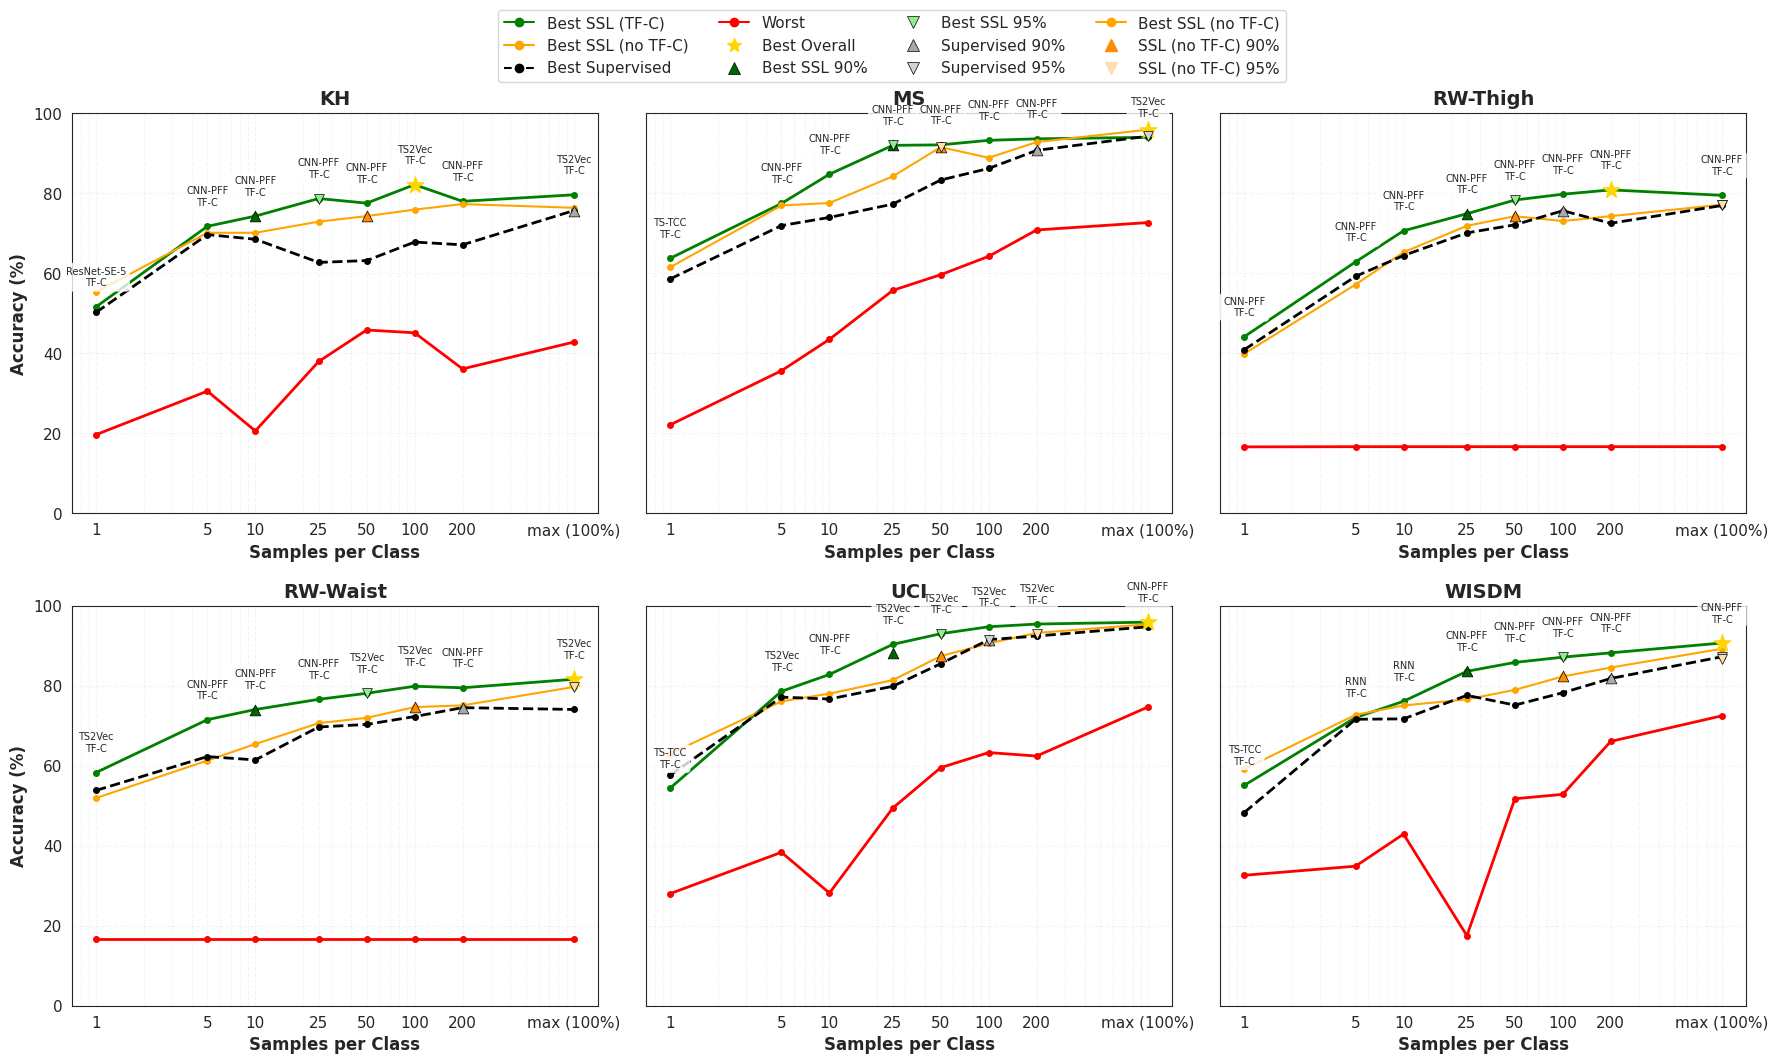

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd

def get_backbone_palette(df):
    unique_backbones = df['Backbone'].unique()
    palette = sns.color_palette("husl", len(unique_backbones))
    return dict(zip(unique_backbones, palette))

daghar_performance = {
    'KH': (82.6, 86.9),        # Time, Frequency
    'MS': (95.8, 93.6),        # Time, Frequency  
    'RW-Thigh': (74.1, 81.5),  # Time, Frequency
    'RW-Waist': (80.6, 84.5),  # Time, Frequency
    'UCI': (96.9, 95.7),       # Time, Frequency
    'WISDM': (90.3, 91.7)      # Time, Frequency
}

def plot_best_worst_techniques(df, daghar_performance=None, best_perf_freeze=None, 
                              include_no_tfc=False, include_freeze=True, include_daghar=True):
    """
    Plot best and worst techniques with optional comparisons
    
    Parameters:
    - df: DataFrame with full finetune results
    - daghar_performance: dict with DAGHAR performance data
    - best_perf_freeze: DataFrame with freeze results  
    - include_no_tfc: bool, whether to include line without TFC
    - include_freeze: bool, whether to include freeze curve
    - include_daghar: bool, whether to include DAGHAR lines
    """
    backbone_palette = get_backbone_palette(df)
    
    # Get best SSL with TFC (original)
    non_supervised = df[df['Technique'] != 'Supervised']
    tfc_df = non_supervised[non_supervised['Technique'] == 'TFC']
    best_tech = tfc_df.loc[tfc_df.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    
    # Get best SSL without TFC if requested
    if include_no_tfc:
        non_supervised_no_tfc = df[df['Technique'] != 'TFC']
        non_supervised_no_tfc = non_supervised_no_tfc[non_supervised_no_tfc['Technique'] != 'Supervised']
        best_tech_no_tfc = non_supervised_no_tfc.loc[non_supervised_no_tfc.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
        best_tech_no_tfc['Type'] = 'Best SSL (no TF-C)'
    
    worst_tech = df.loc[df.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmin()]
    supervised = df[df['Technique'] == 'Supervised']
    best_supervised = supervised.loc[supervised.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    overall_best = df.loc[df.groupby(['Dataset'])['Mean'].idxmax()]
    
    # Calculate thresholds for SSL reaching 90%/95% of max (for Best SSL)
    ssl_90_95 = []
    for dataset in df['Dataset'].unique():
        max_acc = overall_best[overall_best['Dataset'] == dataset]['Mean'].values[0]
        
        # Calculate for Best SSL
        ssl_data = tfc_df[tfc_df['Dataset'] == dataset]
        for threshold in [0.90, 0.95]:
            threshold_acc = max_acc * threshold
            reached = ssl_data[ssl_data['Mean'] >= threshold_acc]
            if not reached.empty:
                first_reached = reached.loc[reached['Data_Percentage'].idxmin()]
                ssl_90_95.append({
                    'Dataset': dataset,
                    'Data_Percentage': first_reached['Data_Percentage'],
                    'Mean': first_reached['Mean'],
                    'Threshold': f"{int(threshold*100)}%",
                    'Backbone': first_reached['Backbone'],
                    'Technique': first_reached['Technique'],
                    'Type': 'Best SSL'
                })
    
    # Calculate thresholds for Supervised
    for dataset in df['Dataset'].unique():
        max_acc = overall_best[overall_best['Dataset'] == dataset]['Mean'].values[0]
        supervised_data = supervised[supervised['Dataset'] == dataset]
        
        for threshold in [0.90, 0.95]:
            threshold_acc = max_acc * threshold
            reached = supervised_data[supervised_data['Mean'] >= threshold_acc]
            if not reached.empty:
                first_reached = reached.loc[reached['Data_Percentage'].idxmin()]
                ssl_90_95.append({
                    'Dataset': dataset,
                    'Data_Percentage': first_reached['Data_Percentage'],
                    'Mean': first_reached['Mean'],
                    'Threshold': f"{int(threshold*100)}%",
                    'Backbone': first_reached['Backbone'],
                    'Technique': first_reached['Technique'],
                    'Type': 'Best Supervised'
                })
    
    # Calculate thresholds for Best SSL without TFC
    if include_no_tfc:
        for dataset in df['Dataset'].unique():
            max_acc = overall_best[overall_best['Dataset'] == dataset]['Mean'].values[0]
            ssl_data_no_tfc = non_supervised_no_tfc[non_supervised_no_tfc['Dataset'] == dataset]
            
            for threshold in [0.90, 0.95]:
                threshold_acc = max_acc * threshold
                reached = ssl_data_no_tfc[ssl_data_no_tfc['Mean'] >= threshold_acc]
                if not reached.empty:
                    first_reached = reached.loc[reached['Data_Percentage'].idxmin()]
                    ssl_90_95.append({
                        'Dataset': dataset,
                        'Data_Percentage': first_reached['Data_Percentage'],
                        'Mean': first_reached['Mean'],
                        'Threshold': f"{int(threshold*100)}%",
                        'Backbone': first_reached['Backbone'],
                        'Technique': first_reached['Technique'],
                        'Type': 'Best SSL (no TF-C)'
                    })
    
    # Calculate thresholds for Freeze
    if include_freeze and best_perf_freeze is not None:
        for dataset in df['Dataset'].unique():
            if dataset in best_perf_freeze['Dataset'].values:
                max_acc = overall_best[overall_best['Dataset'] == dataset]['Mean'].values[0]
                freeze_data = best_perf_freeze[best_perf_freeze['Dataset'] == dataset]
                
                for threshold in [0.90, 0.95]:
                    threshold_acc = max_acc * threshold
                    reached = freeze_data[freeze_data['Mean'] >= threshold_acc]
                    if not reached.empty:
                        first_reached = reached.loc[reached['Data_Percentage'].idxmin()]
                        ssl_90_95.append({
                            'Dataset': dataset,
                            'Data_Percentage': first_reached['Data_Percentage'],
                            'Mean': first_reached['Mean'],
                            'Threshold': f"{int(threshold*100)}%",
                            'Backbone': first_reached['Backbone'],
                            'Technique': first_reached['Technique'],
                            'Type': 'Best Freeze'
                        })
    
    ssl_90_95_df = pd.DataFrame(ssl_90_95)
    
    # Combine all data for plotting
    best_tech['Type'] = 'Best SSL'
    worst_tech['Type'] = 'Worst'
    best_supervised['Type'] = 'Best Supervised'
    
    combined = pd.concat([best_tech, worst_tech, best_supervised])
    if include_no_tfc:
        combined = pd.concat([combined, best_tech_no_tfc])
    if include_freeze and best_perf_freeze is not None:
        best_freeze = best_perf_freeze.loc[best_perf_freeze.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
        best_freeze['Type'] = 'Best Freeze'
        combined = pd.concat([combined, best_freeze])
    
    # Setup plotting
    sns.set_style("white")
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'legend.fontsize': 11
    })
    
    datasets = combined['Dataset'].unique()
    n_cols = 3
    n_rows = int(np.ceil(len(datasets) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows), sharey=True)
    axes = axes.flatten()
    
    # Define color palette
    palette = {
        'Best SSL': 'green', 
        'Best SSL (no TF-C)': 'orange',
        'Best Freeze': 'blue',
        'Worst': 'red', 
        'Best Supervised': 'black'
    }
    
    # Define markers for thresholds - DIFFERENT COLORS for different types
    threshold_markers = {
        'Best SSL': {'90%': ('^', 'darkgreen'), '95%': ('v', 'lightgreen')},
        'Best Supervised': {'90%': ('^', 'darkgray'), '95%': ('v', 'lightgray')},
        'Best SSL (no TF-C)': {'90%': ('^', 'darkorange'), '95%': ('v', 'navajowhite')},
        'Best Freeze': {'90%': ('^', 'darkblue'), '95%': ('v', 'lightblue')}
    }
    
    for i, dataset in enumerate(datasets):
        ax = axes[i]
        subset = combined[combined['Dataset'] == dataset]
        dataset_best = overall_best[overall_best['Dataset'] == dataset]
        dataset_thresholds = ssl_90_95_df[ssl_90_95_df['Dataset'] == dataset]
        
        # Plot main curves
        for typ, typ_df in subset.groupby('Type'):
            color = palette.get(typ, 'gray')
            linestyle = '-' if 'SSL' in typ or 'Freeze' in typ else ('--' if 'Supervised' in typ else '-')
            linewidth = 2 if typ == 'Best SSL' else (1.5 if typ in ['Best SSL (no TF-C)', 'Best Freeze'] else 2)
            
            ax.plot(typ_df['Data_Percentage'], typ_df['Mean'], 
                    color=color, marker='o', linestyle=linestyle,
                    label=typ, linewidth=linewidth, markersize=4)
            
            # Add annotations ONLY for Best SSL (not for no TFC, Freeze, or Supervised)
            if typ == 'Best SSL':
                for _, row in typ_df.iterrows():
                    backbone_name = row['Backbone']
                    if backbone_name == 'TS2Vec Encoder':
                        backbone_name = 'TS2Vec'
                    elif backbone_name == 'TS-TCC Encoder':
                        backbone_name = 'TS-TCC'
                    elif backbone_name == 'IMU Transformer':
                        backbone_name = 'IMU Trans.'

                    
                    
                    # label = f"{backbone_name}\n{row['Technique']}"
                    label = f"{backbone_name}\nTF-C"
                    
                    ax.annotate(label,
                                (row['Data_Percentage'], row['Mean']),
                                textcoords="offset points",
                                xytext=(0, 15),  # Fixed offset for Best SSL
                                ha='center', fontsize=7,
                                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
        
        # Best overall marker
        if not dataset_best.empty:
            ax.scatter(dataset_best['Data_Percentage'], dataset_best['Mean'],
                       marker='*', s=150, color='gold', zorder=5, label='Best Overall')
        
        # Threshold markers for all curve types - DIFFERENT COLORS for different types
        for _, row in dataset_thresholds.iterrows():
            typ_markers = threshold_markers.get(row['Type'], {})
            if row['Threshold'] in typ_markers:
                marker, color = typ_markers[row['Threshold']]
                
                size = 60 if row['Threshold'] == '90%' else 50  # Smaller markers
                
                ax.scatter(row['Data_Percentage'], row['Mean'],
                           marker=marker, s=size, color=color, zorder=5,
                           edgecolors='black', linewidth=0.5)

        # ---- DAGHAR lines ----
        if include_daghar and daghar_performance and dataset in daghar_performance:
            time_acc, freq_acc = daghar_performance[dataset]
            ax.axhline(y=time_acc, color='gray', linestyle='--', linewidth=1, alpha=0.8)
            ax.axhline(y=freq_acc, color='brown', linestyle='-.', linewidth=1, alpha=0.8)
        
        # Axis settings
        ax.set_xscale('log')
        ax.set_xticks([1, 5, 10, 25, 50, 100, 200, 1000])
        ax.set_xticklabels(['1', '5', '10', '25', '50', '100', '200', 'max (100%)'])
        ax.set_xlabel('Samples per Class', fontweight='bold')
        ax.set_ylabel('Accuracy (%)' if i % n_cols == 0 else '', fontweight='bold')
        ax.set_title(dataset, fontweight='bold')
        ax.set_ylim(0, 100)
        ax.grid(True, which="both", ls="--", alpha=0.2)

    # Remove empty subplots
    for j in range(len(datasets), len(axes)):
        fig.delaxes(axes[j])
    
    # Create legend handles
    handles = [
        Line2D([0], [0], color=palette['Best SSL'], marker='o', linestyle='-', label='Best SSL (TF-C)'),
        Line2D([0], [0], color=palette['Best SSL (no TF-C)'], marker='o', linestyle='-', label='Best SSL (no TF-C)'),
        Line2D([0], [0], color=palette['Best Supervised'], marker='o', linestyle='--', label='Best Supervised'),
        Line2D([0], [0], color=palette['Worst'], marker='o', linestyle='-', label='Worst'),
        Line2D([0], [0], marker='*', color='gold', linestyle='None', markersize=10, label='Best Overall'),
    ]
    
    # Add threshold markers to legend
    threshold_legend_items = [
        ('Best SSL 90%', 'darkgreen', '^'),
        ('Best SSL 95%', 'lightgreen', 'v'),
        ('Supervised 90%', 'darkgray', '^'), 
        ('Supervised 95%', 'lightgray', 'v')
    ]
    
    for label, color, marker in threshold_legend_items:
        handles.append(Line2D([0], [0], marker=marker, color=color, linestyle='None', 
                            markersize=8, label=label, markeredgecolor='black', markeredgewidth=0.5))
    
    # Add optional legend items
    if include_no_tfc:
        handles.append(Line2D([0], [0], color=palette['Best SSL (no TF-C)'], marker='o', linestyle='-', label='Best SSL (no TF-C)'))
        # Add threshold markers for no TFC
        handles.extend([
            Line2D([0], [0], marker='^', color='darkorange', linestyle='None', markersize=8, label='SSL (no TF-C) 90%'),
            Line2D([0], [0], marker='v', color='navajowhite', linestyle='None', markersize=8, label='SSL (no TF-C) 95%')
        ])
    
    if include_freeze and best_perf_freeze is not None:
        handles.append(Line2D([0], [0], color=palette['Best Freeze'], marker='o', linestyle='-', label='Best Freeze'))
        # Add threshold markers for freeze
        handles.extend([
            Line2D([0], [0], marker='^', color='darkblue', linestyle='None', markersize=8, label='Freeze 90%'),
            Line2D([0], [0], marker='v', color='lightblue', linestyle='None', markersize=8, label='Freeze 95%')
        ])
    
    if include_daghar and daghar_performance:
        handles.extend([
            Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='DAGHAR (Time)'),
            Line2D([0], [0], color='brown', linestyle='-.', linewidth=2, label='DAGHAR (Freq)')
        ])
    
    # Create legend
    n_cols_legend = min(4, len(handles))
    fig.legend(handles=handles, loc='upper center', ncol=n_cols_legend, bbox_to_anchor=(0.5, 1.07))
    
    plt.tight_layout()
    
    # Generate filename based on options
    filename_parts = ['best_worst_techniques']
    if include_no_tfc:
        filename_parts.append('no_tfc')
    if include_freeze:
        filename_parts.append('freeze')
    if include_daghar:
        filename_parts.append('daghar')
    
    filename = '_'.join(filename_parts) + '.png'
    plt.savefig(filename, format='png', bbox_inches='tight', dpi=300)
    plt.show()

# Example usage:
print("Plot with all options:")
plot_best_worst_techniques(best_perf_ft, daghar_performance, best_perf_freeze, 
                          include_no_tfc=True, include_freeze=False, include_daghar=False)

Plot with all options:


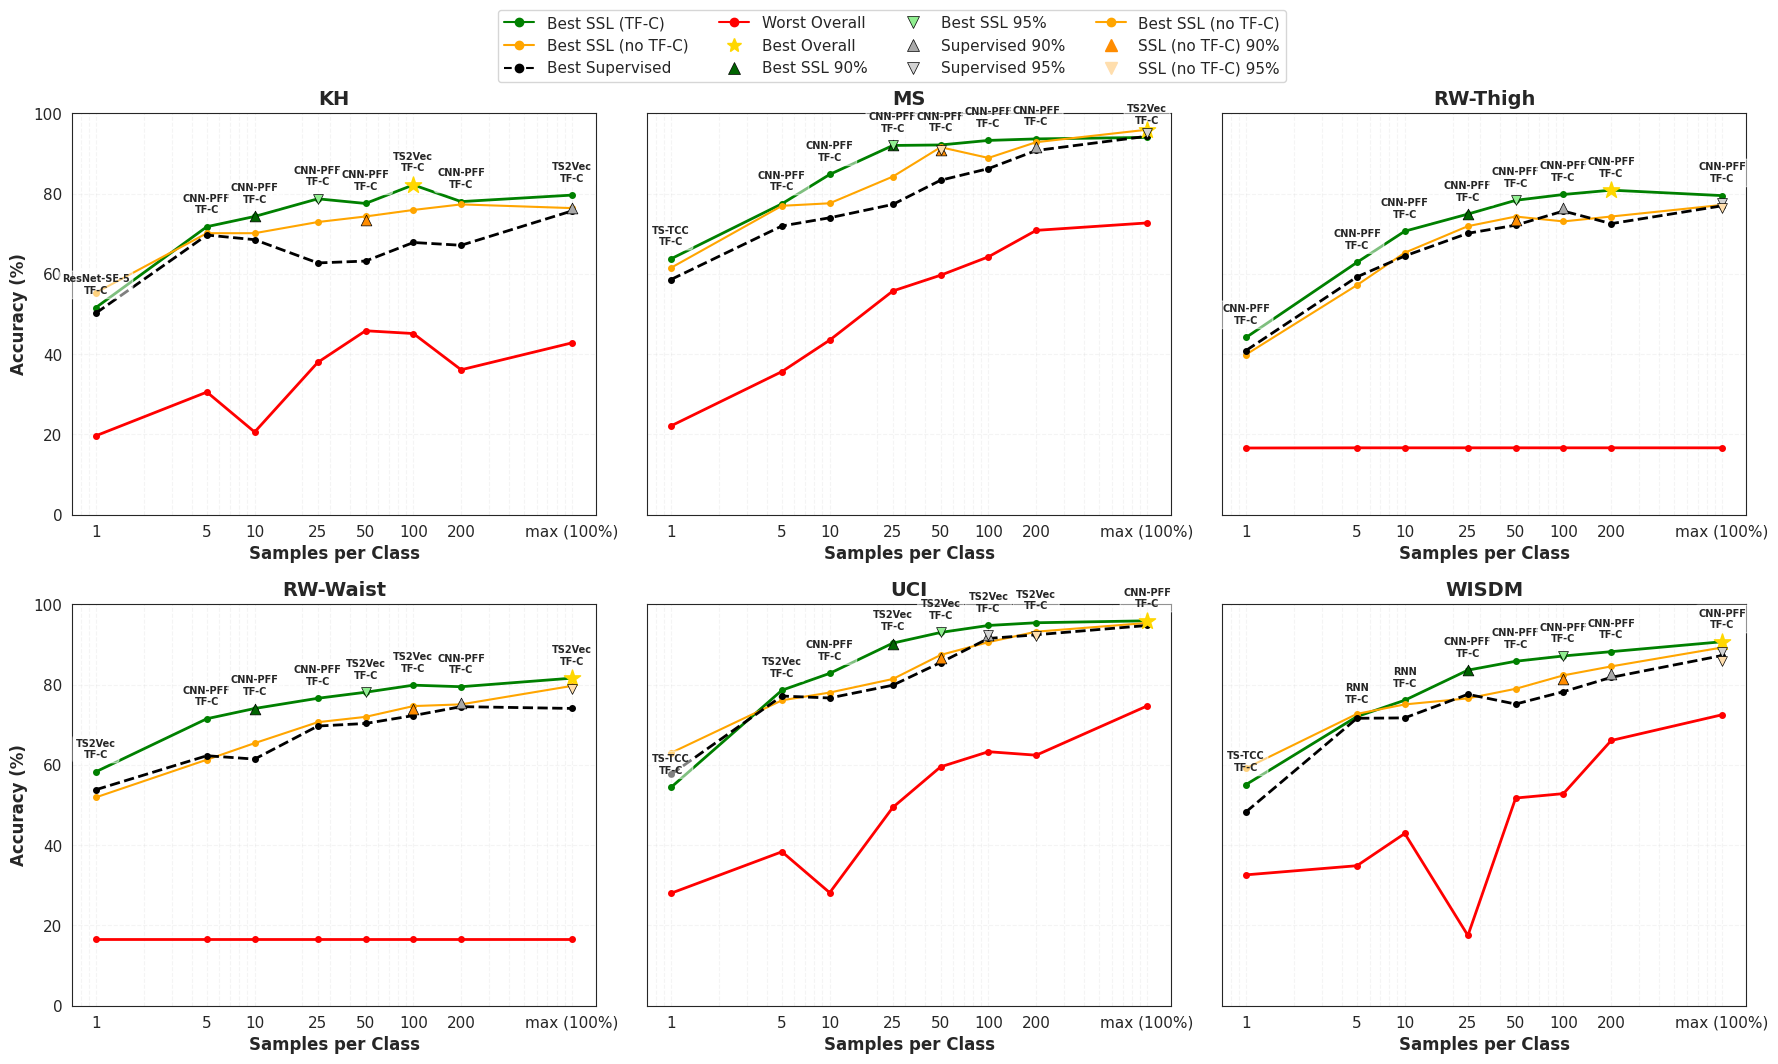

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd

def get_backbone_palette(df):
    unique_backbones = df['Backbone'].unique()
    palette = sns.color_palette("husl", len(unique_backbones))
    return dict(zip(unique_backbones, palette))

daghar_performance = {
    'KH': (82.6, 86.9),        # Time, Frequency
    'MS': (95.8, 93.6),        # Time, Frequency  
    'RW-Thigh': (74.1, 81.5),  # Time, Frequency
    'RW-Waist': (80.6, 84.5),  # Time, Frequency
    'UCI': (96.9, 95.7),       # Time, Frequency
    'WISDM': (90.3, 91.7)      # Time, Frequency
}

def plot_best_worst_techniques(df, daghar_performance=None, best_perf_freeze=None, 
                              include_no_tfc=False, include_freeze=True, include_daghar=True):
    """
    Plot best and worst techniques with optional comparisons
    
    Parameters:
    - df: DataFrame with full finetune results
    - daghar_performance: dict with DAGHAR performance data
    - best_perf_freeze: DataFrame with freeze results  
    - include_no_tfc: bool, whether to include line without TFC
    - include_freeze: bool, whether to include freeze curve
    - include_daghar: bool, whether to include DAGHAR lines
    """
    backbone_palette = get_backbone_palette(df)
    
    # Get best SSL with TFC (original)
    non_supervised = df[df['Technique'] != 'Supervised']
    tfc_df = non_supervised[non_supervised['Technique'] == 'TFC']
    best_tech = tfc_df.loc[tfc_df.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    
    # Get best SSL without TFC if requested
    if include_no_tfc:
        non_supervised_no_tfc = df[df['Technique'] != 'TFC']
        non_supervised_no_tfc = non_supervised_no_tfc[non_supervised_no_tfc['Technique'] != 'Supervised']
        best_tech_no_tfc = non_supervised_no_tfc.loc[non_supervised_no_tfc.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
        best_tech_no_tfc['Type'] = 'Best SSL (no TF-C)'
    
    worst_tech = df.loc[df.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmin()]
    supervised = df[df['Technique'] == 'Supervised']
    best_supervised = supervised.loc[supervised.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
    overall_best = df.loc[df.groupby(['Dataset'])['Mean'].idxmax()]
    
    # Calculate thresholds for SSL reaching 90%/95% of max (for Best SSL)
    ssl_90_95 = []
    for dataset in df['Dataset'].unique():
        max_acc = overall_best[overall_best['Dataset'] == dataset]['Mean'].values[0]
        
        # Calculate for Best SSL
        ssl_data = tfc_df[tfc_df['Dataset'] == dataset]
        for threshold in [0.90, 0.95]:
            threshold_acc = max_acc * threshold
            reached = ssl_data[ssl_data['Mean'] >= threshold_acc]
            if not reached.empty:
                first_reached = reached.loc[reached['Data_Percentage'].idxmin()]
                ssl_90_95.append({
                    'Dataset': dataset,
                    'Data_Percentage': first_reached['Data_Percentage'],
                    'Mean': first_reached['Mean'],
                    'Threshold': f"{int(threshold*100)}%",
                    'Backbone': first_reached['Backbone'],
                    'Technique': first_reached['Technique'],
                    'Type': 'Best SSL'
                })
    
    # Calculate thresholds for Supervised
    for dataset in df['Dataset'].unique():
        max_acc = overall_best[overall_best['Dataset'] == dataset]['Mean'].values[0]
        supervised_data = supervised[supervised['Dataset'] == dataset]
        
        for threshold in [0.90, 0.95]:
            threshold_acc = max_acc * threshold
            reached = supervised_data[supervised_data['Mean'] >= threshold_acc]
            if not reached.empty:
                first_reached = reached.loc[reached['Data_Percentage'].idxmin()]
                ssl_90_95.append({
                    'Dataset': dataset,
                    'Data_Percentage': first_reached['Data_Percentage'],
                    'Mean': first_reached['Mean'],
                    'Threshold': f"{int(threshold*100)}%",
                    'Backbone': first_reached['Backbone'],
                    'Technique': first_reached['Technique'],
                    'Type': 'Best Supervised'
                })
    
    # Calculate thresholds for Best SSL without TFC
    if include_no_tfc:
        for dataset in df['Dataset'].unique():
            max_acc = overall_best[overall_best['Dataset'] == dataset]['Mean'].values[0]
            ssl_data_no_tfc = non_supervised_no_tfc[non_supervised_no_tfc['Dataset'] == dataset]
            
            for threshold in [0.90, 0.95]:
                threshold_acc = max_acc * threshold
                reached = ssl_data_no_tfc[ssl_data_no_tfc['Mean'] >= threshold_acc]
                if not reached.empty:
                    first_reached = reached.loc[reached['Data_Percentage'].idxmin()]
                    ssl_90_95.append({
                        'Dataset': dataset,
                        'Data_Percentage': first_reached['Data_Percentage'],
                        'Mean': first_reached['Mean'],
                        'Threshold': f"{int(threshold*100)}%",
                        'Backbone': first_reached['Backbone'],
                        'Technique': first_reached['Technique'],
                        'Type': 'Best SSL (no TF-C)'
                    })
    
    # Calculate thresholds for Freeze
    if include_freeze and best_perf_freeze is not None:
        for dataset in df['Dataset'].unique():
            if dataset in best_perf_freeze['Dataset'].values:
                max_acc = overall_best[overall_best['Dataset'] == dataset]['Mean'].values[0]
                freeze_data = best_perf_freeze[best_perf_freeze['Dataset'] == dataset]
                
                for threshold in [0.90, 0.95]:
                    threshold_acc = max_acc * threshold
                    reached = freeze_data[freeze_data['Mean'] >= threshold_acc]
                    if not reached.empty:
                        first_reached = reached.loc[reached['Data_Percentage'].idxmin()]
                        ssl_90_95.append({
                            'Dataset': dataset,
                            'Data_Percentage': first_reached['Data_Percentage'],
                            'Mean': first_reached['Mean'],
                            'Threshold': f"{int(threshold*100)}%",
                            'Backbone': first_reached['Backbone'],
                            'Technique': first_reached['Technique'],
                            'Type': 'Best Freeze'
                        })
    
    ssl_90_95_df = pd.DataFrame(ssl_90_95)
    
    # Combine all data for plotting
    best_tech['Type'] = 'Best SSL'
    worst_tech['Type'] = 'Worst'
    best_supervised['Type'] = 'Best Supervised'
    
    combined = pd.concat([best_tech, worst_tech, best_supervised])
    if include_no_tfc:
        combined = pd.concat([combined, best_tech_no_tfc])
    if include_freeze and best_perf_freeze is not None:
        best_freeze = best_perf_freeze.loc[best_perf_freeze.groupby(['Dataset', 'Data_Percentage'])['Mean'].idxmax()]
        best_freeze['Type'] = 'Best Freeze'
        combined = pd.concat([combined, best_freeze])
    
    # Setup plotting
    sns.set_style("white")
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'legend.fontsize': 11
    })
    
    datasets = combined['Dataset'].unique()
    n_cols = 3
    n_rows = int(np.ceil(len(datasets) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows), sharey=True)
    axes = axes.flatten()
    
    # Define color palette
    palette = {
        'Best SSL': 'green', 
        'Best SSL (no TF-C)': 'orange',
        'Best Freeze': 'blue',
        'Worst': 'red', 
        'Best Supervised': 'black'
    }
    
    # Define markers for thresholds - DIFFERENT COLORS for different types
    threshold_markers = {
        'Best SSL': {'90%': ('^', 'darkgreen'), '95%': ('v', 'lightgreen')},
        'Best Supervised': {'90%': ('^', 'darkgray'), '95%': ('v', 'lightgray')},
        'Best SSL (no TF-C)': {'90%': ('^', 'darkorange'), '95%': ('v', 'navajowhite')},
        'Best Freeze': {'90%': ('^', 'darkblue'), '95%': ('v', 'lightblue')}
    }
    
    for i, dataset in enumerate(datasets):
        ax = axes[i]
        subset = combined[combined['Dataset'] == dataset]
        dataset_best = overall_best[overall_best['Dataset'] == dataset]
        dataset_thresholds = ssl_90_95_df[ssl_90_95_df['Dataset'] == dataset]
        
        # Plot main curves
        for typ, typ_df in subset.groupby('Type'):
            color = palette.get(typ, 'gray')
            linestyle = '-' if 'SSL' in typ or 'Freeze' in typ else ('--' if 'Supervised' in typ else '-')
            linewidth = 2 if typ == 'Best SSL' else (1.5 if typ in ['Best SSL (no TF-C)', 'Best Freeze'] else 2)
            
            ax.plot(typ_df['Data_Percentage'], typ_df['Mean'], 
                    color=color, marker='o', linestyle=linestyle,
                    label=typ, linewidth=linewidth, markersize=4)
            
            # Add annotations ONLY for Best SSL (not for no TFC, Freeze, or Supervised)
            if typ == 'Best SSL':
                for _, row in typ_df.iterrows():
                    backbone_name = row['Backbone']
                    if backbone_name == 'TS2Vec Encoder':
                        backbone_name = 'TS2Vec'
                    elif backbone_name == 'TS-TCC Encoder':
                        backbone_name = 'TS-TCC'
                    elif backbone_name == 'IMU Transformer':
                        backbone_name = 'IMU Trans.'

                    
                    
                    # label = f"{backbone_name}\n{row['Technique']}"
                    label = f"{backbone_name}\nTF-C"
                    
                    ax.annotate(label,
                                (row['Data_Percentage'], row['Mean']),
                                textcoords="offset points",
                                xytext=(0, 10),  # Fixed offset for Best SSL
                                ha='center', fontsize=7, fontweight='bold',
                                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5))
        
        # Best overall marker
        if not dataset_best.empty:
            ax.scatter(dataset_best['Data_Percentage'], dataset_best['Mean'],
                       marker='*', s=150, color='gold', zorder=5, label='Best Overall')
        
        # Threshold markers for all curve types - DIFFERENT COLORS for different types
        for _, row in dataset_thresholds.iterrows():
            typ_markers = threshold_markers.get(row['Type'], {})
            if row['Threshold'] in typ_markers:
                marker, color = typ_markers[row['Threshold']]
                
                size = 60 if row['Threshold'] == '90%' else 50  # Smaller markers
                
                # ax.scatter(row['Data_Percentage'], row['Mean'],
                #            marker=marker, s=size, color=color, zorder=5,
                #            edgecolors='black', linewidth=0.5)

                type_offset = {
                    'Best SSL': 0.0,
                    'Best Supervised': 0.8,
                    'Best SSL (no TF-C)': -0.8,
                    'Best Freeze': 0.8
                }

                y_offset = type_offset.get(row['Type'], 0.0)
                if row['Dataset'] == 'UCI' and row['Data_Percentage'] == 25:
                    y_offset += 2.0
                ax.scatter(
                    row['Data_Percentage'],
                    row['Mean'] + y_offset,
                    marker=marker,
                    s=size,
                    color=color,
                    zorder=5,
                    edgecolors='black',
                    linewidth=0.5
                )

        # ---- DAGHAR lines ----
        if include_daghar and daghar_performance and dataset in daghar_performance:
            time_acc, freq_acc = daghar_performance[dataset]
            ax.axhline(y=time_acc, color='gray', linestyle='--', linewidth=1, alpha=0.8)
            ax.axhline(y=freq_acc, color='brown', linestyle='-.', linewidth=1, alpha=0.8)
        
        # Axis settings
        ax.set_xscale('log')
        ax.set_xticks([1, 5, 10, 25, 50, 100, 200, 1000])
        ax.set_xticklabels(['1', '5', '10', '25', '50', '100', '200', 'max (100%)'])
        ax.set_xlabel('Samples per Class', fontweight='bold')
        ax.set_ylabel('Accuracy (%)' if i % n_cols == 0 else '', fontweight='bold')
        ax.set_title(dataset, fontweight='bold')
        ax.set_ylim(0, 100)
        ax.grid(True, which="both", ls="--", alpha=0.2)

    # Remove empty subplots
    for j in range(len(datasets), len(axes)):
        fig.delaxes(axes[j])
    
    # Create legend handles
    handles = [
        Line2D([0], [0], color=palette['Best SSL'], marker='o', linestyle='-', label='Best SSL (TF-C)'),
        Line2D([0], [0], color=palette['Best SSL (no TF-C)'], marker='o', linestyle='-', label='Best SSL (no TF-C)'),
        Line2D([0], [0], color=palette['Best Supervised'], marker='o', linestyle='--', label='Best Supervised'),
        Line2D([0], [0], color=palette['Worst'], marker='o', linestyle='-', label='Worst Overall'),
        Line2D([0], [0], marker='*', color='gold', linestyle='None', markersize=10, label='Best Overall'),
    ]
    
    # Add threshold markers to legend
    threshold_legend_items = [
        ('Best SSL 90%', 'darkgreen', '^'),
        ('Best SSL 95%', 'lightgreen', 'v'),
        ('Supervised 90%', 'darkgray', '^'), 
        ('Supervised 95%', 'lightgray', 'v')
    ]
    
    for label, color, marker in threshold_legend_items:
        handles.append(Line2D([0], [0], marker=marker, color=color, linestyle='None', 
                            markersize=8, label=label, markeredgecolor='black', markeredgewidth=0.5))
    
    # Add optional legend items
    if include_no_tfc:
        handles.append(Line2D([0], [0], color=palette['Best SSL (no TF-C)'], marker='o', linestyle='-', label='Best SSL (no TF-C)'))
        # Add threshold markers for no TFC
        handles.extend([
            Line2D([0], [0], marker='^', color='darkorange', linestyle='None', markersize=8, label='SSL (no TF-C) 90%'),
            Line2D([0], [0], marker='v', color='navajowhite', linestyle='None', markersize=8, label='SSL (no TF-C) 95%')
        ])
    
    if include_freeze and best_perf_freeze is not None:
        handles.append(Line2D([0], [0], color=palette['Best Freeze'], marker='o', linestyle='-', label='Best Freeze'))
        # Add threshold markers for freeze
        handles.extend([
            Line2D([0], [0], marker='^', color='darkblue', linestyle='None', markersize=8, label='Freeze 90%'),
            Line2D([0], [0], marker='v', color='lightblue', linestyle='None', markersize=8, label='Freeze 95%')
        ])
    
    if include_daghar and daghar_performance:
        handles.extend([
            Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='DAGHAR (Time)'),
            Line2D([0], [0], color='brown', linestyle='-.', linewidth=2, label='DAGHAR (Freq)')
        ])
    
    # Create legend
    n_cols_legend = min(4, len(handles))
    fig.legend(handles=handles, loc='upper center', ncol=n_cols_legend, bbox_to_anchor=(0.5, 1.07))
    
    plt.tight_layout()
    
    # Generate filename based on options
    filename_parts = ['best_worst_techniques']
    if include_no_tfc:
        filename_parts.append('no_tfc')
    if include_freeze:
        filename_parts.append('freeze')
    if include_daghar:
        filename_parts.append('daghar')
    
    filename = '_'.join(filename_parts) + '.png'
    plt.savefig(filename, format='png', bbox_inches='tight', dpi=300)
    plt.show()

# Example usage:
print("Plot with all options:")
plot_best_worst_techniques(best_perf_ft, daghar_performance, best_perf_freeze, 
                          include_no_tfc=True, include_freeze=False, include_daghar=False)